In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler , MinMaxScaler

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

### 1. Problem statement

### 2. data gathering

In [2]:
df = pd.read_csv("personal_loan_dataset.csv")          # load the data set
df.head()

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
0,APP100000,59,Male,Married,2,Graduate,Salaried,12.2,75200.0,346000,36,17.57,Wedding,1,12434.22,0.324,611.0,0,1,1
1,APP100001,49,Male,Single,1,Graduate,Self-Employed,3.1,66500.0,771000,12,15.87,Home Renovation,0,69906.07,1.051,602.0,0,1,0
2,APP100002,35,Female,Married,3,Graduate,Business Owner,4.2,30900.0,64000,12,16.15,Business,1,5811.32,0.308,490.0,0,2,0
3,APP100003,63,Male,Single,0,High School,Salaried,1.3,26500.0,350000,36,17.08,Medical,1,12492.39,0.604,506.0,0,1,0
4,APP100004,28,Male,Widowed,0,High School,Salaried,NaN,29500.0,127000,48,17.12,Education,1,3672.48,0.301,479.0,0,3,1


### 3. EDA ( Exploratory Data Analysis )

In [3]:
df.shape         # total number or rows and columns

(10035, 20)

In [4]:
rows , columns = df.shape
print("total rows are = ",rows)                 # returns total rows
print("total columns are = ",columns)           # return total columns

total rows are =  10035
total columns are =  20


In [5]:
df.columns     # return all coluumns names

Index(['Applicant_ID', 'Age', 'Gender', 'Marital_Status', 'Dependents',
       'Education', 'Employment_Type', 'Years_of_Employment', 'Monthly_Income',
       'Loan_Amount', 'Loan_Term', 'Interest_Rate', 'Loan_Purpose',
       'Existing_Loan', 'Monthly_EMI', 'Debt_to_Income_Ratio', 'Credit_Score',
       'Previous_Default', 'Number_of_Late_Payments', 'Loan_Status'],
      dtype='object')

In [6]:
df.dtypes         # check data type of each column

Applicant_ID                object
Age                          int64
Gender                      object
Marital_Status              object
Dependents                   int64
Education                   object
Employment_Type             object
Years_of_Employment        float64
Monthly_Income             float64
Loan_Amount                  int64
Loan_Term                    int64
Interest_Rate              float64
Loan_Purpose                object
Existing_Loan                int64
Monthly_EMI                float64
Debt_to_Income_Ratio       float64
Credit_Score               float64
Previous_Default             int64
Number_of_Late_Payments      int64
Loan_Status                  int64
dtype: object

In [7]:
df_num = df.select_dtypes(include="number")       # check only numeric columns
df_num.head()

,Age,Dependents,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
0,59,2,12.2,75200.0,346000,36,17.57,1,12434.22,0.324,611.0,0,1,1
1,49,1,3.1,66500.0,771000,12,15.87,0,69906.07,1.051,602.0,0,1,0
2,35,3,4.2,30900.0,64000,12,16.15,1,5811.32,0.308,490.0,0,2,0
3,63,0,1.3,26500.0,350000,36,17.08,1,12492.39,0.604,506.0,0,1,0
4,28,0,NaN,29500.0,127000,48,17.12,1,3672.48,0.301,479.0,0,3,1


In [8]:
df_obj = df.select_dtypes(include="object")      # checking categorical column
df_obj.head()

,Applicant_ID,Gender,Marital_Status,Education,Employment_Type,Loan_Purpose
0,APP100000,Male,Married,Graduate,Salaried,Wedding
1,APP100001,Male,Single,Graduate,Self-Employed,Home Renovation
2,APP100002,Female,Married,Graduate,Business Owner,Business
3,APP100003,Male,Single,High School,Salaried,Medical
4,APP100004,Male,Widowed,High School,Salaried,Education


In [9]:
df_date = df.select_dtypes(include="datetime")    # check date column
df_date.head()

""
0
1
2
3
4


In [10]:
# Identify identifier columns
# An identifier column is a column whose only purpose is to uniquely identify each record.
df["Applicant_ID"].nunique()

10000

In [11]:
len(df)        # there are 10035 records present in Dataset.   but we get only 10000 unique values. means duplicate Application Id are exist

10035

In [12]:
df["Applicant_ID"].duplicated().sum()    #  total duplicate application id 35

np.int64(35)

In [13]:
df[df["Applicant_ID"].duplicated(keep=False)]    # keep = false  will show all the duplicates including first occurence also

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
130,APP100130,25,Male,Married,1,Graduate,Business Owner,4.0,20000.0,174000,36,17.05,Debt Consolidation,1,6207.91,0.431,482.0,0,4,1
1217,APP101217,34,Male,Married,3,Graduate,Salaried,7.8,17000.0,223000,24,15.37,Business,1,10851.77,0.731,520.0,0,1,0
1266,APP101266,37,Female,Married,1,Graduate,Business Owner,3.1,84200.0,377000,36,13.51,Travel,0,12795.43,0.152,626.0,0,2,1
1768,APP101768,37,Male,Single,0,Graduate,Salaried,0.1,98200.0,638000,60,17.81,Other,1,16135.14,0.272,528.0,0,4,0
1933,APP101933,30,Male,Married,0,Graduate,Salaried,0.1,30600.0,110000,36,15.88,Other,0,3860.76,0.126,547.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10030,APP101768,37,Male,Single,0,Graduate,Salaried,0.1,98200.0,638000,60,17.81,Other,1,16135.14,0.272,528.0,0,4,0
10031,APP109059,39,Female,Married,3,Graduate,Self-Employed,15.6,38800.0,332000,36,15.19,Business,1,11539.80,0.453,613.0,0,2,1
10032,APP105512,35,Female,Single,2,Post Graduate,Self-Employed,14.0,23900.0,51000,36,15.18,Debt Consolidation,0,1772.43,0.074,627.0,0,2,1
10033,APP106343,40,Male,Married,0,Graduate,Self-Employed,8.4,53500.0,636000,36,15.43,Other,0,22181.31,0.415,575.0,0,1,0


In [14]:
df[df["Applicant_ID"].duplicated(keep=False)] ["Applicant_ID"]     # display only duplicate id

130      APP100130
1217     APP101217
1266     APP101266
1768     APP101768
1933     APP101933
           ...    
10030    APP101768
10031    APP109059
10032    APP105512
10033    APP106343
10034    APP106702
Name: Applicant_ID, Length: 70, dtype: object

In [15]:
df.isna().sum()                # missing values in each column

Applicant_ID                 0
Age                          0
Gender                     100
Marital_Status             150
Dependents                   0
Education                    0
Employment_Type              0
Years_of_Employment        200
Monthly_Income             100
Loan_Amount                  0
Loan_Term                    0
Interest_Rate              150
Loan_Purpose               100
Existing_Loan                0
Monthly_EMI                  0
Debt_to_Income_Ratio       200
Credit_Score               150
Previous_Default             0
Number_of_Late_Payments      0
Loan_Status                  0
dtype: int64

In [16]:
df.isna().mean() * 100           # percentage of missing values of each column

Applicant_ID               0.000000
Age                        0.000000
Gender                     0.996512
Marital_Status             1.494768
Dependents                 0.000000
Education                  0.000000
Employment_Type            0.000000
Years_of_Employment        1.993024
Monthly_Income             0.996512
Loan_Amount                0.000000
Loan_Term                  0.000000
Interest_Rate              1.494768
Loan_Purpose               0.996512
Existing_Loan              0.000000
Monthly_EMI                0.000000
Debt_to_Income_Ratio       1.993024
Credit_Score               1.494768
Previous_Default           0.000000
Number_of_Late_Payments    0.000000
Loan_Status                0.000000
dtype: float64

In [17]:
df.duplicated().sum()             # number of  duplicate records 

np.int64(32)

In [18]:
df_duplicate = df[df.duplicated()]          #  check duplicate records
df_duplicate.head()

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
10000,APP109953,30,Female,Married,2,Doctorate,Salaried,2.6,91400.0,1097000,12,16.40,Debt Consolidation,1,99739.52,1.200,531.0,0,2,0
10001,APP103850,65,Female,Divorced,2,High School,Business Owner,2.4,22800.0,238000,48,14.84,Other,1,6604.43,0.476,579.0,0,2,1
10002,APP104962,60,Male,Married,3,Post Graduate,Salaried,1.0,135600.0,933000,48,15.12,Home Renovation,1,26022.88,0.377,601.0,0,0,1
10003,APP103886,51,Female,Married,0,Post Graduate,Salaried,2.0,48400.0,109000,48,16.06,Travel,0,3092.44,0.064,495.0,0,2,0
10004,APP105437,61,Male,Single,0,Doctorate,Salaried,4.5,46100.0,558000,24,16.26,Medical,0,27390.79,0.594,606.0,0,3,0


In [19]:
df_num.columns

Index(['Age', 'Dependents', 'Years_of_Employment', 'Monthly_Income',
       'Loan_Amount', 'Loan_Term', 'Interest_Rate', 'Existing_Loan',
       'Monthly_EMI', 'Debt_to_Income_Ratio', 'Credit_Score',
       'Previous_Default', 'Number_of_Late_Payments', 'Loan_Status'],
      dtype='object')

In [20]:
# checking min and max values of each columns

for col in df_num.columns:
    print("column name: ",col)
    print("min values: ",df[col].min())
    print("max_value: ",df[col].max())
    print("--"*30)

column name:  Age
min values:  -3
max_value:  150
------------------------------------------------------------
column name:  Dependents
min values:  0
max_value:  4
------------------------------------------------------------
column name:  Years_of_Employment
min values:  0.0
max_value:  36.0
------------------------------------------------------------
column name:  Monthly_Income
min values:  8000.0
max_value:  887963.9408647977
------------------------------------------------------------
column name:  Loan_Amount
min values:  20000
max_value:  2475942
------------------------------------------------------------
column name:  Loan_Term
min values:  12
max_value:  84
------------------------------------------------------------
column name:  Interest_Rate
min values:  10.87
max_value:  24.0
------------------------------------------------------------
column name:  Existing_Loan
min values:  0
max_value:  1
------------------------------------------------------------
column name:  Monthl

In [21]:
# Loan_Term column    we will check loan tenure This indicates that loans are offered only for predefined durations.

df["Loan_Term"].unique()

array([36, 12, 48, 24, 60, 84])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_ID             10035 non-null  object 
 1   Age                      10035 non-null  int64  
 2   Gender                   9935 non-null   object 
 3   Marital_Status           9885 non-null   object 
 4   Dependents               10035 non-null  int64  
 5   Education                10035 non-null  object 
 6   Employment_Type          10035 non-null  object 
 7   Years_of_Employment      9835 non-null   float64
 8   Monthly_Income           9935 non-null   float64
 9   Loan_Amount              10035 non-null  int64  
 10  Loan_Term                10035 non-null  int64  
 11  Interest_Rate            9885 non-null   float64
 12  Loan_Purpose             9935 non-null   object 
 13  Existing_Loan            10035 non-null  int64  
 14  Monthly_EMI           

In [23]:
# only age column contains invalid value


In [24]:
# checking invalid values exist or not

df[(df["Age"] <= 0)  | (df["Age"] > 100)]     # age is less than 0 or more than 100 these are invalid values

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
5080,APP105080,150,Female,Married,0,Graduate,Salaried,1.4,18900.0,44000,60,16.39,Wedding,0,1079.13,0.057,528.0,0,1,0
6811,APP106811,-3,Male,Widowed,3,Graduate,Salaried,2.9,50200.0,684000,24,14.81,Home Renovation,0,33103.15,0.659,616.0,0,0,0


In [25]:
df[df["Years_of_Employment"] < 0]       # it should be greater than 0

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [26]:
df[df["Monthly_Income"] <=0 ]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [27]:
df[df["Loan_Amount"] < 0]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [28]:
df[df["Loan_Term"] < 0]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [29]:
df[df["Interest_Rate"] < 0]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [30]:
df[df["Monthly_EMI"] <= 0]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [31]:
df[df["Debt_to_Income_Ratio"] < 0]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [32]:
df[ (df["Credit_Score"] < 300) | (df["Credit_Score"] > 900)]   # credit score should be in 300 to 900.   it means this are invalid values

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
1462,APP101462,64,Male,Married,0,High School,Salaried,3.7,22600.0,49000,12,17.81,Education,0,4487.89,0.199,950.0,0,1,1
9718,APP109718,29,Male,Single,4,Graduate,Salaried,5.2,37100.0,468000,48,20.23,Home Renovation,0,14298.82,0.385,-50.0,1,6,0


In [33]:
df[df["Number_of_Late_Payments"] < 0]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status


In [34]:
# checking unique values of each columns in the data set

In [35]:
df["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

In [36]:
df["Marital_Status"].unique()

array(['Married', 'Single', 'Widowed', nan, 'Divorced'], dtype=object)

In [37]:
df["Dependents"].unique()

array([2, 1, 3, 0, 4])

In [38]:
df["Education"].unique()

array(['Graduate', 'High School', 'Post Graduate', 'Doctorate'],
      dtype=object)

In [39]:
df["Employment_Type"].unique()

array(['Salaried', 'Self-Employed', 'Business Owner', 'Unemployed'],
      dtype=object)

In [40]:
# display unique values of each columns

for col in df.columns:
    print("column name: ",col)
    print("unique values",df[col].unique())
    print("---" * 30)

column name:  Applicant_ID
unique values ['APP100000' 'APP100001' 'APP100002' ... 'APP109997' 'APP109998'
 'APP109999']
------------------------------------------------------------------------------------------
column name:  Age
unique values [ 59  49  35  63  28  41  39  43  31  44  56  60  23  42  22  64  50  58
  53  32  45  47  62  48  36  57  27  29  38  24  34  46  40  55  37  26
  54  30  51  65  61  21  25  33  52 150  -3]
------------------------------------------------------------------------------------------
column name:  Gender
unique values ['Male' 'Female' nan]
------------------------------------------------------------------------------------------
column name:  Marital_Status
unique values ['Married' 'Single' 'Widowed' nan 'Divorced']
------------------------------------------------------------------------------------------
column name:  Dependents
unique values [2 1 3 0 4]
------------------------------------------------------------------------------------------
colu

In [41]:
df.info()           # information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_ID             10035 non-null  object 
 1   Age                      10035 non-null  int64  
 2   Gender                   9935 non-null   object 
 3   Marital_Status           9885 non-null   object 
 4   Dependents               10035 non-null  int64  
 5   Education                10035 non-null  object 
 6   Employment_Type          10035 non-null  object 
 7   Years_of_Employment      9835 non-null   float64
 8   Monthly_Income           9935 non-null   float64
 9   Loan_Amount              10035 non-null  int64  
 10  Loan_Term                10035 non-null  int64  
 11  Interest_Rate            9885 non-null   float64
 12  Loan_Purpose             9935 non-null   object 
 13  Existing_Loan            10035 non-null  int64  
 14  Monthly_EMI           

In [42]:
df.describe()                # statistical summary of numeric columns

,Age,Dependents,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
count,10035.000000,10035.000000,9835.000000,9935.000000,1.003500e+04,10035.000000,9885.000000,10035.000000,10035.000000,9835.000000,9885.000000,10035.000000,10035.000000,10035.000000
mean,43.047135,1.265272,4.173574,46191.587147,3.826465e+05,38.481315,16.689467,0.405082,16136.439600,0.411883,561.340718,0.217638,2.467663,0.435974
std,12.946690,1.221928,4.291784,40428.818926,3.101681e+05,18.433854,1.810859,0.490932,16665.312568,0.267229,50.832503,0.412661,2.129462,0.495908
min,-3.000000,0.000000,0.000000,8000.000000,2.000000e+04,12.000000,10.870000,0.000000,415.190000,0.039000,-50.000000,0.000000,0.000000,0.000000
25%,32.000000,0.000000,1.000000,25600.000000,1.680000e+05,24.000000,15.400000,0.000000,6020.170000,0.235000,527.000000,0.000000,1.000000,0.000000
50%,43.000000,1.000000,2.900000,38400.000000,3.010000e+05,36.000000,16.470000,0.000000,11231.300000,0.357000,561.000000,0.000000,2.000000,0.000000
75%,54.000000,2.000000,6.000000,57300.000000,4.990000e+05,48.000000,17.790000,1.000000,20185.450000,0.516000,595.000000,0.000000,3.000000,1.000000
max,150.000000,4.000000,36.000000,887963.940865,2.475942e+06,84.000000,24.000000,1.000000,186409.970000,8.500000,950.000000,1.000000,14.000000,1.000000


In [43]:
# Overall Dataset Observations:
    # Missing values are present in several numerical columns (count is less than 10,035).
    # Invalid values are present in Age (-3, 150) and Credit_Score (-50, 950).
    # Numerical features such as Monthly_Income, Loan_Amount, and Monthly_EMI appear to be right-skewed.
    # Debt_to_Income_Ratio contains very high values that should be investigated as potential outliers.
    # Binary features (Existing_Loan, Previous_Default, Loan_Status) contain only valid 0/1 values.

In [44]:
df.describe(include="all")

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status
count,10035,10035.000000,9935,9885,10035.000000,10035,10035,9835.000000,9935.000000,1.003500e+04,10035.000000,9885.000000,9935,10035.000000,10035.000000,9835.000000,9885.000000,10035.000000,10035.000000,10035.000000
unique,10000,NaN,2,4,NaN,4,4,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,APP109059,NaN,Male,Married,NaN,Graduate,Salaried,NaN,NaN,NaN,NaN,NaN,Debt Consolidation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,5827,5054,NaN,4534,5459,NaN,NaN,NaN,NaN,NaN,1697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,43.047135,NaN,NaN,1.265272,NaN,NaN,4.173574,46191.587147,3.826465e+05,38.481315,16.689467,NaN,0.405082,16136.439600,0.411883,561.340718,0.217638,2.467663,0.435974
std,NaN,12.946690,NaN,NaN,1.221928,NaN,NaN,4.291784,40428.818926,3.101681e+05,18.433854,1.810859,NaN,0.490932,16665.312568,0.267229,50.832503,0.412661,2.129462,0.495908
min,NaN,-3.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,8000.000000,2.000000e+04,12.000000,10.870000,NaN,0.000000,415.190000,0.039000,-50.000000,0.000000,0.000000,0.000000
25%,NaN,32.000000,NaN,NaN,0.000000,NaN,NaN,1.000000,25600.000000,1.680000e+05,24.000000,15.400000,NaN,0.000000,6020.170000,0.235000,527.000000,0.000000,1.000000,0.000000
50%,NaN,43.000000,NaN,NaN,1.000000,NaN,NaN,2.900000,38400.000000,3.010000e+05,36.000000,16.470000,NaN,0.000000,11231.300000,0.357000,561.000000,0.000000,2.000000,0.000000
75%,NaN,54.000000,NaN,NaN,2.000000,NaN,NaN,6.000000,57300.000000,4.990000e+05,48.000000,17.790000,NaN,1.000000,20185.450000,0.516000,595.000000,0.000000,3.000000,1.000000


#### Univarite analysis

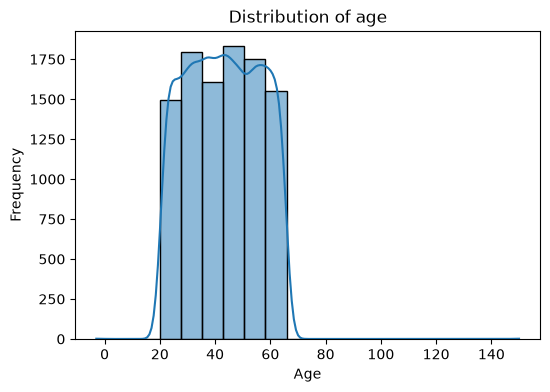

In [45]:
# age              # Approximately uniform

plt.figure(figsize=(6,4))
sns.histplot(df["Age"],kde=True, bins=20)

plt.title("Distribution of age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

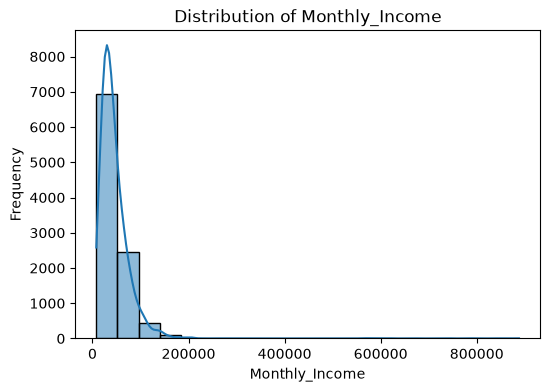

In [46]:
# Monthly_Income       # positively skewed (right-skewed).   very less people earns more money

plt.figure(figsize=(6,4))
sns.histplot(df["Monthly_Income"],kde=True, bins=20)

plt.title("Distribution of Monthly_Income")
plt.xlabel("Monthly_Income")
plt.ylabel("Frequency")
plt.show()

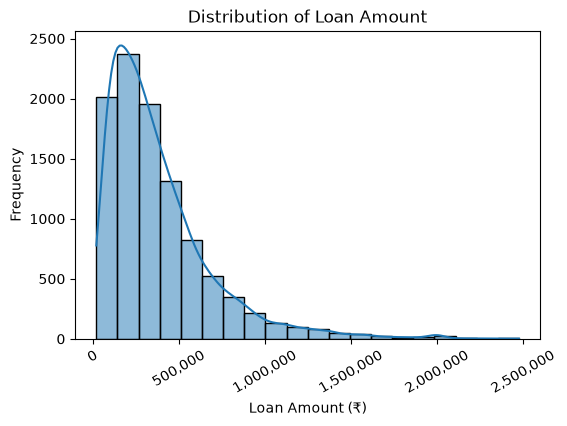

In [47]:
# Loan_Amount       # positively skewed (right-skewed).  

import matplotlib.ticker as ticker

plt.figure(figsize=(6,4))
sns.histplot(df["Loan_Amount"], bins=20, kde=True)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount (₹)")
plt.ylabel("Frequency")

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=30)
plt.show()

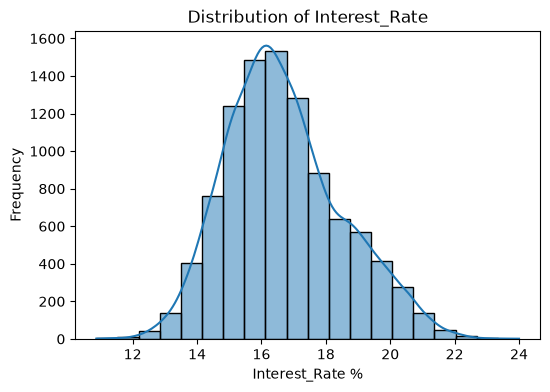

In [48]:
# Interest_Rate        # interest rate  is Approximately normal

plt.figure(figsize=(6,4))
sns.histplot(df["Interest_Rate"],kde=True, bins=20)

plt.title("Distribution of Interest_Rate")
plt.xlabel("Interest_Rate %")
plt.ylabel("Frequency")
plt.show()

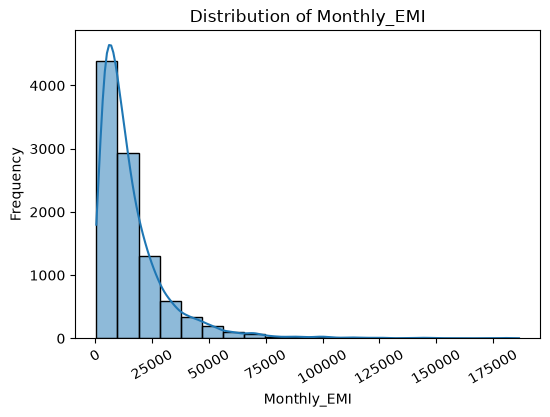

In [49]:
# Monthly_EMI      # positively skewed (right-skewed).  

plt.figure(figsize=(6,4))
sns.histplot(df["Monthly_EMI"],kde=True, bins=20)

plt.title("Distribution of Monthly_EMI")
plt.xlabel("Monthly_EMI")
plt.ylabel("Frequency")
plt.xticks(rotation=30)
plt.show()

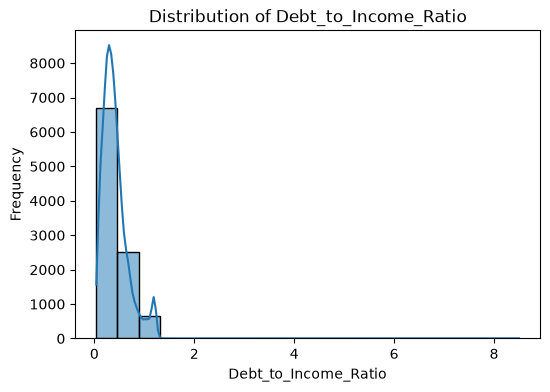

In [50]:
# Debt_to_Income_Ratio     #  highly positively (right) skewed.

plt.figure(figsize=(6,4))
sns.histplot(df["Debt_to_Income_Ratio"],kde=True, bins=20)

plt.title("Distribution of Debt_to_Income_Ratio")
plt.xlabel("Debt_to_Income_Ratio")
plt.ylabel("Frequency")
plt.show()

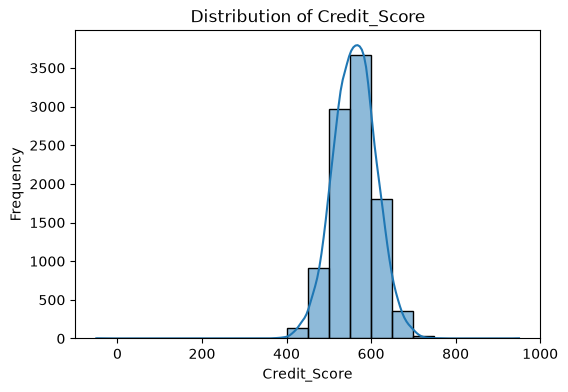

In [51]:
# Credit_Score       # credit score is Approximately normally distributued

plt.figure(figsize=(6,4))
sns.histplot(df["Credit_Score"],kde=True, bins=20)

plt.title("Distribution of Credit_Score")
plt.xlabel("Credit_Score")
plt.ylabel("Frequency")
plt.show()

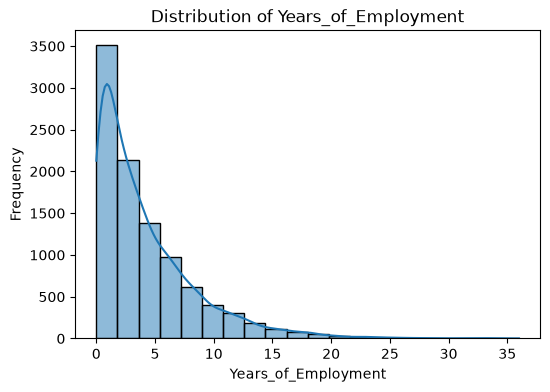

In [52]:
# Years_of_Employment       #  highly positively (right) skewed.

plt.figure(figsize=(6,4))
sns.histplot(df["Years_of_Employment"],kde=True, bins=20)

plt.title("Distribution of Years_of_Employment")
plt.xlabel("Years_of_Employment")
plt.ylabel("Frequency")
plt.show()

In [53]:
#chceking outliers to numeric featues  in graphical (visual) format.    using boxplot

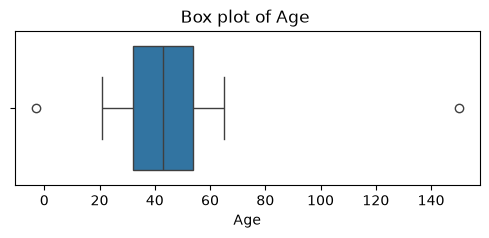

******************************************************************************************


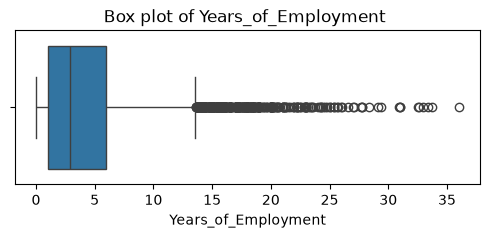

******************************************************************************************


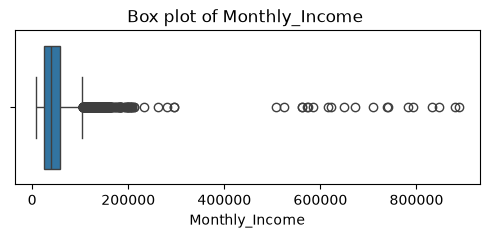

******************************************************************************************


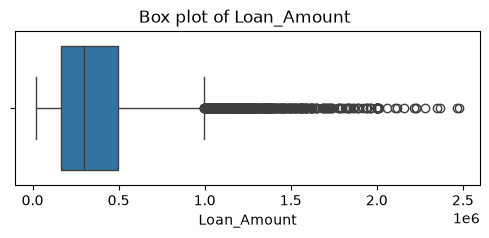

******************************************************************************************


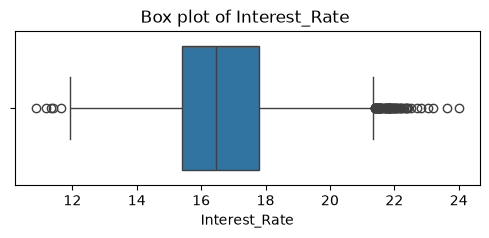

******************************************************************************************


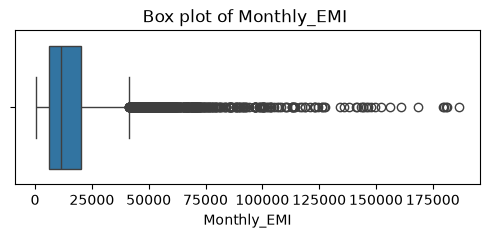

******************************************************************************************


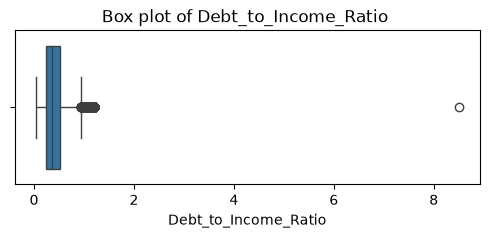

******************************************************************************************


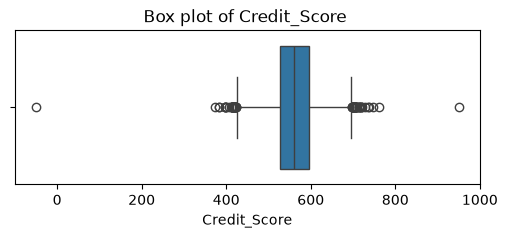

******************************************************************************************


In [54]:
continuous_cols = [
    "Age",
    "Years_of_Employment",
    "Monthly_Income",
    "Loan_Amount",
    "Interest_Rate",
    "Monthly_EMI",
    "Debt_to_Income_Ratio",
    "Credit_Score"
]

for col in continuous_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x = df[col])
    plt.title(f"Box plot of {col} ")
    plt.show()
    print("***" * 30)

In [55]:
# checking outliers values and counts using IQR  method.   based on this we will think to  keep or remove the outliers.

In [56]:

# checking outliers in age column
col = "Age"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

print("Column :", col)
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)
print("Number of Outliers :", len(outliers))

Column : Age
Q1 : 32.0
Q3 : 54.0
IQR : 22.0
Lower Limit : -1.0
Upper Limit : 87.0
Number of Outliers : 2


In [57]:
# finding outliers of all columns at once

continuous_cols = [
    "Age",
    "Years_of_Employment",
    "Monthly_Income",
    "Loan_Amount",
    "Interest_Rate",
    "Monthly_EMI",
    "Debt_to_Income_Ratio",
    "Credit_Score"
]

for col in continuous_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print("="*60)
    print(f"Column : {col}")
    print(f"Lower Limit : {lower_limit:.2f}")       # :.2f  meanin   ==>   : means  Now I'm going to specify how to format this value.
    print(f"Upper Limit : {upper_limit:.2f}")                           #  .2  means   Show only 2 digits after the decimal point.
    print(f"Outliers : {len(outliers)}")

Column : Age
Lower Limit : -1.00
Upper Limit : 87.00
Outliers : 2
Column : Years_of_Employment
Lower Limit : -6.50
Upper Limit : 13.50
Outliers : 405
Column : Monthly_Income
Lower Limit : -21950.00
Upper Limit : 104850.00
Outliers : 411
Column : Loan_Amount
Lower Limit : -328500.00
Upper Limit : 995500.00
Outliers : 482
Column : Interest_Rate
Lower Limit : 11.82
Upper Limit : 21.37
Outliers : 73
Column : Monthly_EMI
Lower Limit : -15227.75
Upper Limit : 41433.37
Outliers : 670
Column : Debt_to_Income_Ratio
Lower Limit : -0.19
Upper Limit : 0.94
Outliers : 566
Column : Credit_Score
Lower Limit : 425.00
Upper Limit : 697.00
Outliers : 73


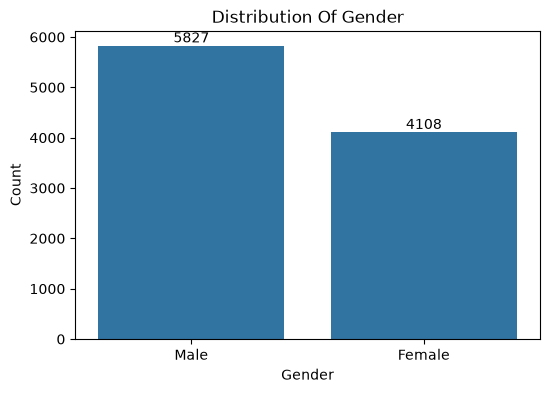

In [58]:
# categorical variable analysis

# Gender column

plt.figure(figsize=(6,4))
ax = sns.countplot(x="Gender", data=df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Distribution Of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

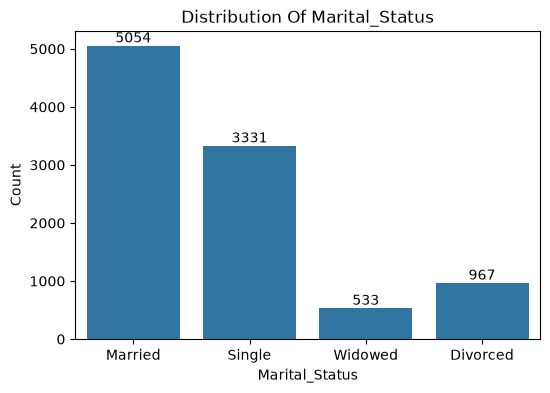

In [59]:
# Marital_Status

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Marital_Status", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution Of Marital_Status")
plt.xlabel("Marital_Status")
plt.ylabel("Count")
plt.show()

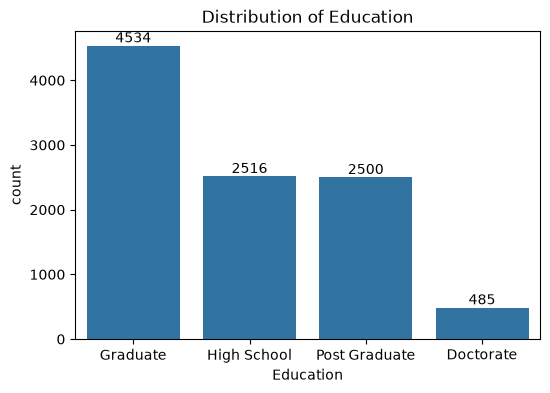

In [60]:
# Education

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Education" ,data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Education")
plt.xlabel("Education")
plt.ylabel("count")
plt.show()

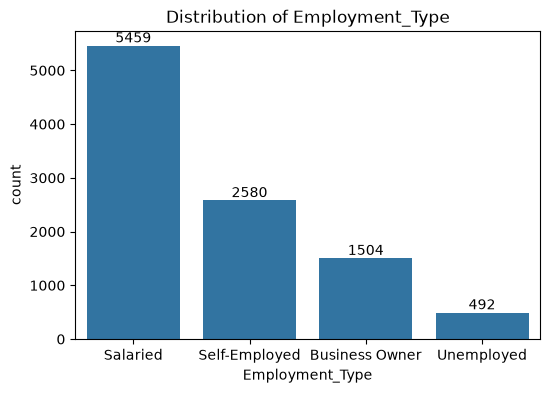

In [61]:
# Employment_Type

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Employment_Type" , data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Employment_Type")
plt.xlabel("Employment_Type")
plt.ylabel("count")
plt.show()

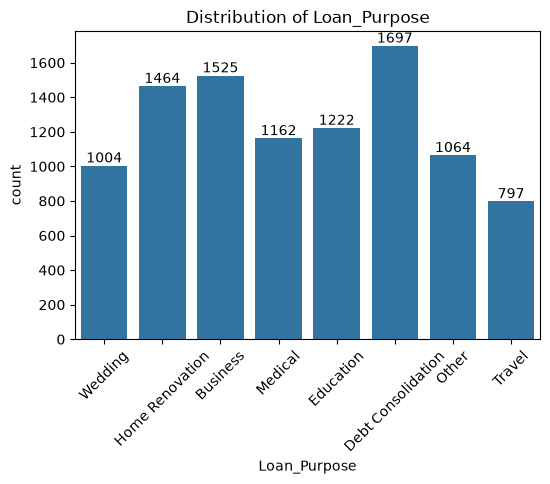

In [62]:
# Loan_Purpose

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Loan_Purpose" , data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Loan_Purpose")
plt.xlabel("Loan_Purpose")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

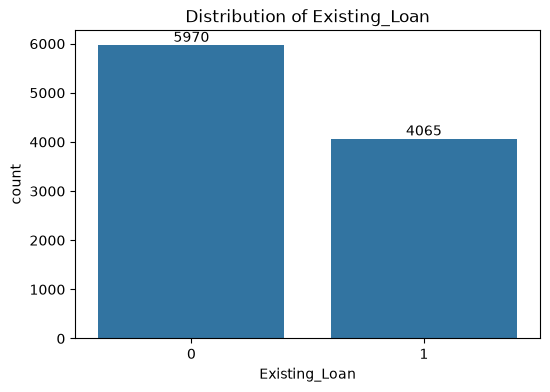

In [63]:
# Existing_Loan            0 (No Existing Loan)    and        1 (Has Existing Loan) 

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Existing_Loan" , data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Existing_Loan")
plt.xlabel("Existing_Loan")
plt.ylabel("count")
plt.show()

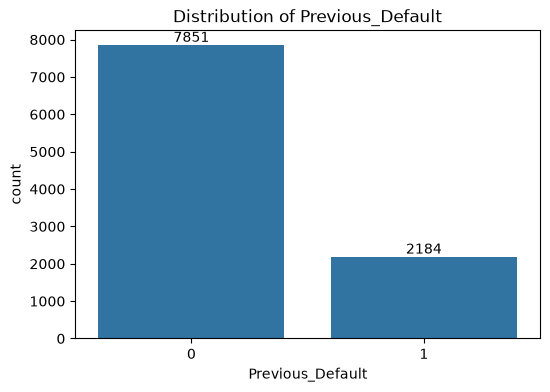

In [64]:
# Previous_Default         0 (No Previous Default)    and      1 (Previous Default)

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Previous_Default" , data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Previous_Default")
plt.xlabel("Previous_Default")
plt.ylabel("count")
plt.show()

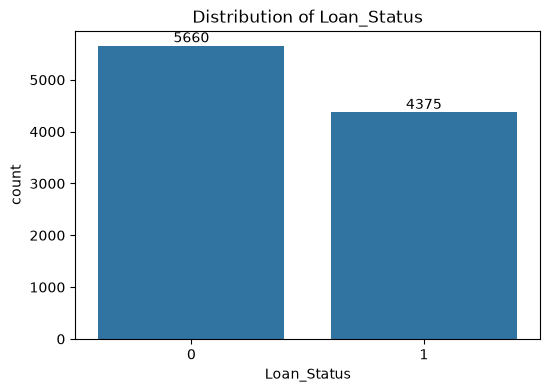

In [65]:
# Loan_Status     remember   Approved (1)   and   Rejected (0)

plt.figure(figsize=(6,4))
ax = sns.countplot(x = "Loan_Status" , data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("count")
plt.show()

### Bivariate analysis

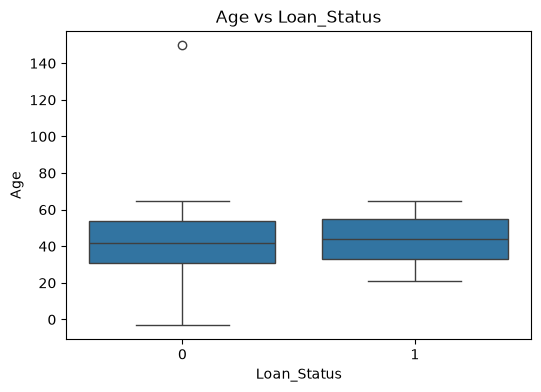

In [66]:
# Age vs Loan_Status                  0 = Rejected    and   1 = Approved

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Age", data=df)

plt.title("Age vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Age")
plt.show()

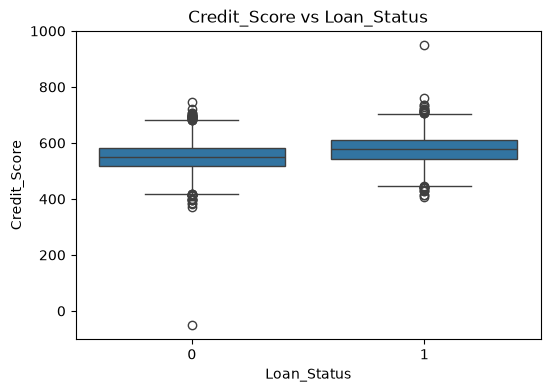

In [67]:
# Credit_Score vs Loan_Status                  0 = Rejected    and   1 = Approved          # imp feature

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Credit_Score", data=df)

plt.title("Credit_Score vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Credit_Score")
plt.show()

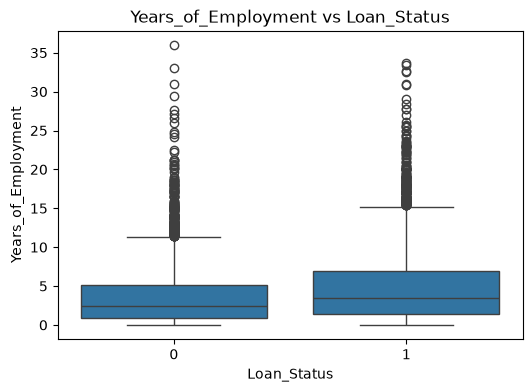

In [68]:
# Years_of_Employment vs Loan_Status                  0 = Rejected    and   1 = Approved    # imp feature

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Years_of_Employment", data=df)

plt.title("Years_of_Employment vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Years_of_Employment")
plt.show()

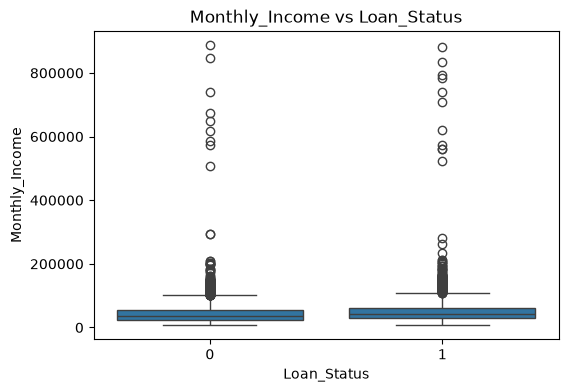

In [69]:
# Monthly_Income vs Loan_Status                  0 = Rejected    and   1 = Approved

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Monthly_Income", data=df)

plt.title("Monthly_Income vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Monthly_Income")
plt.show()

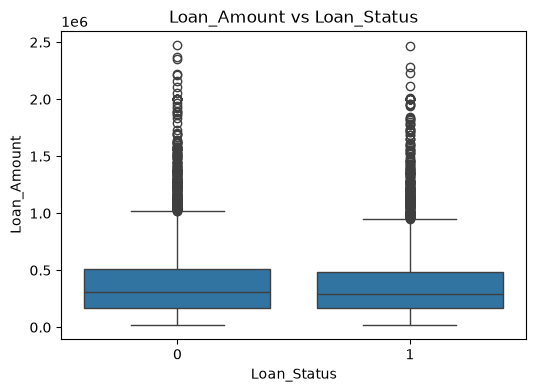

In [70]:
# Loan_Amount vs Loan_Status                  0 = Rejected    and   1 = Approved

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Loan_Amount", data=df)

plt.title("Loan_Amount vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Loan_Amount")
plt.show()

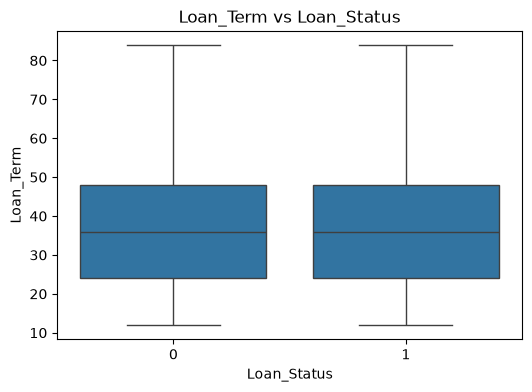

In [71]:
# Loan_Term vs Loan_Status                  0 = Rejected    and   1 = Approved             # not imp feature

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Loan_Term", data=df)

plt.title("Loan_Term vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Loan_Term")
plt.show()

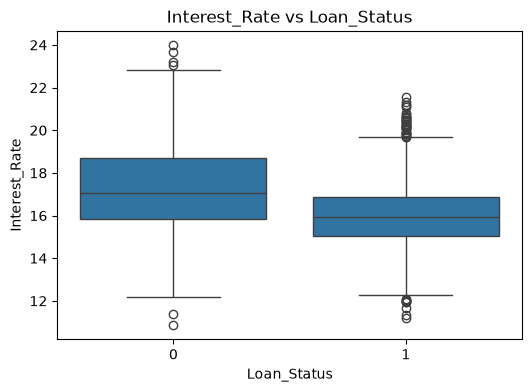

In [72]:
# Interest_Rate vs Loan_Status                  0 = Rejected    and   1 = Approved    # imp feature low interest feature applications are approved most

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Interest_Rate", data=df)

plt.title("Interest_Rate vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Interest_Rate")
plt.show()

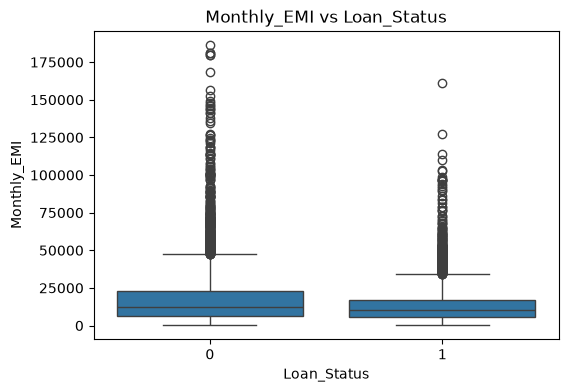

In [73]:
# Monthly_EMI vs Loan_Status                  0 = Rejected    and   1 = Approved

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Monthly_EMI", data=df)

plt.title("Monthly_EMI vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Monthly_EMI")
plt.show()

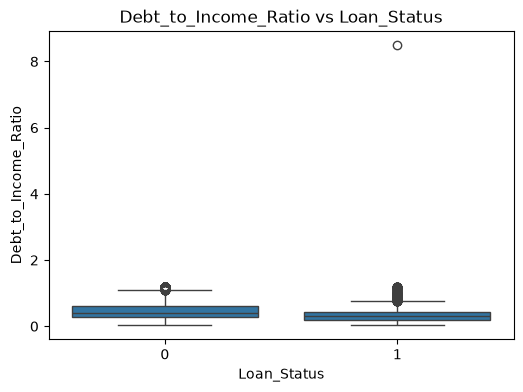

In [74]:
# Debt_to_Income_Ratio vs Loan_Status            0 = Rejected    and   1 = Approved       # imp feature low DTIraito application are mostly approved

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Debt_to_Income_Ratio", data=df)

plt.title("Debt_to_Income_Ratio vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Debt_to_Income_Ratio")
plt.show()

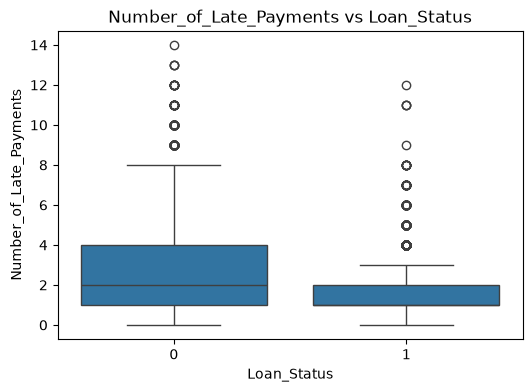

In [75]:
# Number_of_Late_Payments vs Loan_Status          0 = Rejected    and   1 = Approved    # imp feature low late payments has more chances to get approve

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Number_of_Late_Payments", data=df)

plt.title("Number_of_Late_Payments vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Number_of_Late_Payments")
plt.show()

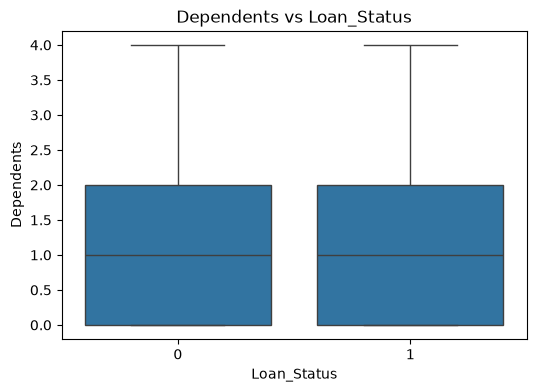

In [76]:
# Dependents vs Loan_Status                  0 = Rejected    and   1 = Approved

plt.figure(figsize=(6,4))
sns.boxplot(x="Loan_Status", y="Dependents", data=df)

plt.title("Dependents vs Loan_Status")
plt.xlabel("Loan_Status")
plt.ylabel("Dependents")
plt.show()

#### correlation matrix of numerical features

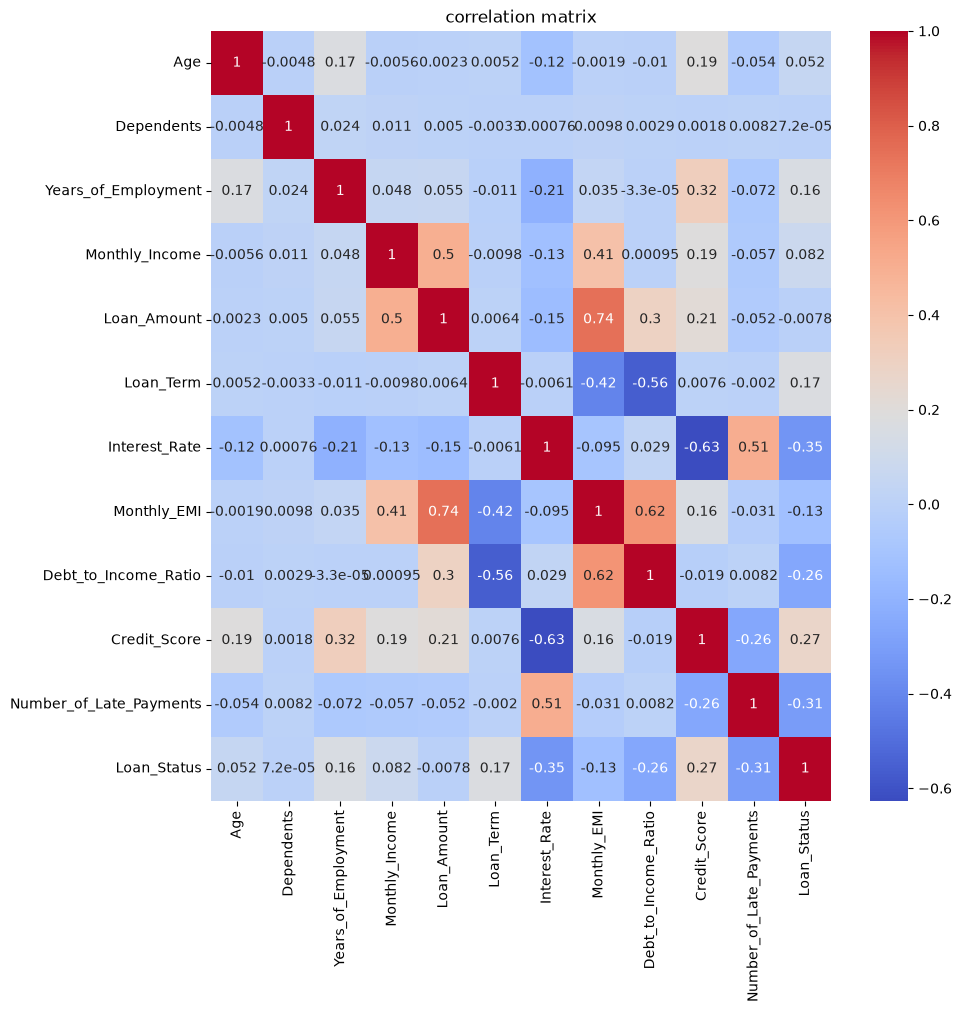

In [77]:
num_cols = [
    "Age",
    "Dependents",
    "Years_of_Employment",
    "Monthly_Income",
    "Loan_Amount",
    "Loan_Term",
    "Interest_Rate",
    "Monthly_EMI",
    "Debt_to_Income_Ratio",
    "Credit_Score",
    "Number_of_Late_Payments",
    "Loan_Status"
]

plt.figure(figsize=(10,10))
sns.heatmap(df[num_cols].corr() , annot=True , cmap="coolwarm",fmt=".2g")

plt.title("correlation matrix")
plt.show()

## Step 2 : Feature Engineering

### 2.12 Loan Amount Category
Create categories such as:
•	Small Loan
•	Medium Loan
•	Large Loan

In [78]:
df["Loan_Amount"].min(),df["Loan_Amount"].max(), df["Loan_Amount"].mean(), df["Loan_Amount"].median()

(20000, 2475942, np.float64(382646.49696063774), 301000.0)

In [79]:
# mean median min and max is not suitable here. because one high loan can change a mean values ,
# so we wlll use quantile

df["Loan_Amount"].quantile([0.33, 0.66])

0.33    208000.0
0.66    413000.0
Name: Loan_Amount, dtype: float64

In [80]:
# use np.select method

conditions = [(df["Loan_Amount"] <= 208000),
             (df["Loan_Amount"] > 208000) & (df["Loan_Amount"] <= 413000),
             (df["Loan_Amount"] > 413000)]

choices = ["Small Loan", "Medium Loan", "Large Loan"]

df["Loan_Amount_Category"] = np.select(conditions,choices, default=None)

In [81]:
df[["Loan_Amount", "Loan_Amount_Category"]].head(10)

,Loan_Amount,Loan_Amount_Category
0,346000,Medium Loan
1,771000,Large Loan
2,64000,Small Loan
3,350000,Medium Loan
4,127000,Small Loan
5,347000,Medium Loan
6,631000,Large Loan
7,177000,Small Loan
8,313000,Medium Loan
9,788000,Large Loan


In [82]:
df["Loan_Amount_Category"].value_counts(dropna=False)

Loan_Amount_Category
Large Loan     3410
Small Loan     3323
Medium Loan    3302
Name: count, dtype: int64

### 2.13 Interest Rate Category
Create categories:
•	Low Interest
•	Medium Interest
•	High Interest

In [83]:
df["Interest_Rate"].quantile([0.33, 0.66])

0.33    15.78
0.66    17.23
Name: Interest_Rate, dtype: float64

In [84]:
conditions = [df["Interest_Rate"] < 15,
             df["Interest_Rate"].between(15,20),
             df["Interest_Rate"] > 20]

choices = ["Low Interest", "Medium Interest", "High Interest"]

df["Interest_Rate_Category"] =  np.select(conditions, choices, default=None)

In [85]:
df[["Interest_Rate","Interest_Rate_Category"]].head(10)

,Interest_Rate,Interest_Rate_Category
0,17.57,Medium Interest
1,15.87,Medium Interest
2,16.15,Medium Interest
3,17.08,Medium Interest
4,17.12,Medium Interest
5,16.52,Medium Interest
6,13.78,Low Interest
7,16.41,Medium Interest
8,20.10,High Interest
9,14.15,Low Interest


In [86]:
df["Interest_Rate_Category"].value_counts(dropna=False)

Interest_Rate_Category
Medium Interest    7686
Low Interest       1684
High Interest       515
None                150
Name: count, dtype: int64

In [87]:
df.groupby("Interest_Rate_Category", dropna=False)["Interest_Rate"].agg(
    ["min", "max", "count"]
)

,min,max,count
Interest_Rate_Category,,,
High Interest,20.01,24.00,515
Low Interest,10.87,14.99,1684
Medium Interest,15.00,20.00,7686
NaN,NaN,NaN,0


## 2.1 Data Cleaning / Preprocessing

### 2.2.1 Handling/removing duplicates

In [88]:
df.duplicated().sum()

np.int64(32)

In [89]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,...,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status,Loan_Amount_Category,Interest_Rate_Category
130,APP100130,25,Male,Married,1,Graduate,Business Owner,4.0,20000.0,174000,...,Debt Consolidation,1,6207.91,0.431,482.0,0,4,1,Small Loan,Medium Interest
1217,APP101217,34,Male,Married,3,Graduate,Salaried,7.8,17000.0,223000,...,Business,1,10851.77,0.731,520.0,0,1,0,Medium Loan,Medium Interest
1266,APP101266,37,Female,Married,1,Graduate,Business Owner,3.1,84200.0,377000,...,Travel,0,12795.43,0.152,626.0,0,2,1,Medium Loan,Low Interest
1768,APP101768,37,Male,Single,0,Graduate,Salaried,0.1,98200.0,638000,...,Other,1,16135.14,0.272,528.0,0,4,0,Large Loan,Medium Interest
1933,APP101933,30,Male,Married,0,Graduate,Salaried,0.1,30600.0,110000,...,Other,0,3860.76,0.126,547.0,0,0,1,Small Loan,Medium Interest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10030,APP101768,37,Male,Single,0,Graduate,Salaried,0.1,98200.0,638000,...,Other,1,16135.14,0.272,528.0,0,4,0,Large Loan,Medium Interest
10031,APP109059,39,Female,Married,3,Graduate,Self-Employed,15.6,38800.0,332000,...,Business,1,11539.80,0.453,613.0,0,2,1,Medium Loan,Medium Interest
10032,APP105512,35,Female,Single,2,Post Graduate,Self-Employed,14.0,23900.0,51000,...,Debt Consolidation,0,1772.43,0.074,627.0,0,2,1,Small Loan,Medium Interest
10033,APP106343,40,Male,Married,0,Graduate,Self-Employed,8.4,53500.0,636000,...,Other,0,22181.31,0.415,575.0,0,1,0,Large Loan,Medium Interest


In [90]:
duplicate_rows.shape

(64, 22)

In [91]:
duplicate_rows["Applicant_ID"].value_counts()

Applicant_ID
APP100130    2
APP101217    2
APP109059    2
APP108517    2
APP108418    2
APP107865    2
APP107781    2
APP107775    2
APP107673    2
APP107039    2
APP106978    2
APP106880    2
APP106702    2
APP106450    2
APP106343    2
APP106111    2
APP105512    2
APP105437    2
APP104962    2
APP103886    2
APP103850    2
APP103092    2
APP102907    2
APP102418    2
APP102370    2
APP102041    2
APP101989    2
APP101988    2
APP101933    2
APP101768    2
APP101266    2
APP109953    2
Name: count, dtype: int64

In [92]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows[
    duplicate_rows["Applicant_ID"] == "APP100130"
]

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,...,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status,Loan_Amount_Category,Interest_Rate_Category
130,APP100130,25,Male,Married,1,Graduate,Business Owner,4.0,20000.0,174000,...,Debt Consolidation,1,6207.91,0.431,482.0,0,4,1,Small Loan,Medium Interest
10025,APP100130,25,Male,Married,1,Graduate,Business Owner,4.0,20000.0,174000,...,Debt Consolidation,1,6207.91,0.431,482.0,0,4,1,Small Loan,Medium Interest


In [93]:
df = df.drop_duplicates()    # we removed duplicate records

In [94]:
df.duplicated().sum()

np.int64(0)

In [95]:
df.shape

(10003, 22)

In [96]:
df["Applicant_ID"].duplicated().sum()   # but there are some records duplicate recrods exist

np.int64(3)

In [97]:
# look they Application Id are same but values are different so we will remove invalid records only
df[df["Applicant_ID"].duplicated(keep=False)].sort_values("Applicant_ID")

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,...,Loan_Purpose,Existing_Loan,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Previous_Default,Number_of_Late_Payments,Loan_Status,Loan_Amount_Category,Interest_Rate_Category
6811,APP106811,-3,Male,Widowed,3,Graduate,Salaried,2.9,50200.000000,684000,...,Home Renovation,0,33103.15,0.659,616.0,0,0,0,Large Loan,Low Interest
10012,APP106811,61,Male,Widowed,3,Graduate,Salaried,2.9,50200.000000,684000,...,Home Renovation,0,33103.15,0.659,616.0,0,0,0,Large Loan,Low Interest
7877,APP107877,46,NaN,NaN,4,Post Graduate,Self-Employed,5.8,32700.000000,377000,...,NaN,0,11192.92,NaN,522.0,0,3,0,Medium Loan,None
10027,APP107877,46,Male,Single,4,Post Graduate,Self-Employed,5.8,32700.000000,377000,...,Wedding,0,11192.92,0.342,522.0,0,3,0,Medium Loan,Medium Interest
9984,APP109984,59,Female,Divorced,0,Post Graduate,Self-Employed,5.8,52100.000000,288000,...,Medical,0,14077.99,0.270,536.0,0,2,1,Medium Loan,Medium Interest
10009,APP109984,59,Female,Divorced,0,Post Graduate,Self-Employed,5.8,572729.986883,288000,...,Medical,0,14077.99,0.270,536.0,0,2,1,Medium Loan,Medium Interest


In [98]:
duplicate_ids = df[df["Applicant_ID"].duplicated(keep=False)]

duplicate_ids[
    [
        "Applicant_ID",
        "Age",
        "Gender",
        "Marital_Status",
        "Monthly_Income",
        "Loan_Amount",
        "Credit_Score",
        "Existing_Loan",
        "Previous_Default",
        "Number_of_Late_Payments",
        "Loan_Status"
    ]
].sort_values("Applicant_ID")

,Applicant_ID,Age,Gender,Marital_Status,Monthly_Income,Loan_Amount,Credit_Score,Existing_Loan,Previous_Default,Number_of_Late_Payments,Loan_Status
6811,APP106811,-3,Male,Widowed,50200.000000,684000,616.0,0,0,0,0
10012,APP106811,61,Male,Widowed,50200.000000,684000,616.0,0,0,0,0
7877,APP107877,46,NaN,NaN,32700.000000,377000,522.0,0,0,3,0
10027,APP107877,46,Male,Single,32700.000000,377000,522.0,0,0,3,0
9984,APP109984,59,Female,Divorced,52100.000000,288000,536.0,0,0,2,1
10009,APP109984,59,Female,Divorced,572729.986883,288000,536.0,0,0,2,1


In [99]:
df[df["Applicant_ID"] == "APP109984"].T

,9984,10009
Applicant_ID,APP109984,APP109984
Age,59,59
Gender,Female,Female
Marital_Status,Divorced,Divorced
Dependents,0,0
Education,Post Graduate,Post Graduate
Employment_Type,Self-Employed,Self-Employed
Years_of_Employment,5.8,5.8
Monthly_Income,52100.0,572729.986883
Loan_Amount,288000,288000


In [100]:
df = df.drop(index=[6811, 7877, 10009])

In [101]:
df["Applicant_ID"].duplicated().sum()   # now there is no duplicate records.

np.int64(0)

In [102]:
df.shape

(10000, 22)

### 2.2.2 Handling Invalid values.

In [103]:
# Age column
df.loc[(df["Age"] < 18) | (df["Age"] > 100) , "Age"] = np.nan

In [104]:
df["Age"].isna().sum()

np.int64(1)

In [105]:
# handling credit score
df.loc[(df["Credit_Score"] < 300) | (df["Credit_Score"] > 900), ["Applicant_ID", "Credit_Score"]]

,Applicant_ID,Credit_Score
1462,APP101462,950.0
9718,APP109718,-50.0


In [106]:
df.loc[(df["Credit_Score"] < 300) | (df["Credit_Score"] > 900), "Credit_Score"] = np.nan

In [107]:
df["Credit_Score"].isna().sum()   # before we have 150 missing values now add this 2 =   so total becomes 152 missing values

np.int64(152)

### 2.2.3. handling missing values

In [108]:
missing_summary = pd.DataFrame({
    "missing_count":df.isna().sum(),
    "missing_percentage":df.isna().mean() * 100 , 
})

In [109]:
missing_summary =  missing_summary [missing_summary["missing_count"]> 0].sort_values("missing_count", ascending=False)
missing_summary

,missing_count,missing_percentage
Years_of_Employment,200,2.00
Debt_to_Income_Ratio,199,1.99
Credit_Score,152,1.52
Marital_Status,149,1.49
Interest_Rate,149,1.49
Interest_Rate_Category,149,1.49
Monthly_Income,100,1.00
Gender,99,0.99
Loan_Purpose,99,0.99
Age,1,0.01


In [110]:
# 1.  fill Years_of_Employment  with using median Imputation
df["Years_of_Employment"].median()

2.9

In [111]:
df["Years_of_Employment"] = df["Years_of_Employment"].fillna(df["Years_of_Employment"].median())

In [112]:
df["Years_of_Employment"].isna().sum()

np.int64(0)

In [113]:
# 2. fill Debt_to_Income_Ratio with using median Imputation
df["Debt_to_Income_Ratio"].median(), df["Debt_to_Income_Ratio"].mean()

(0.357, np.float64(0.4118891949801041))

In [114]:
df["Debt_to_Income_Ratio"] = df["Debt_to_Income_Ratio"].fillna(df["Debt_to_Income_Ratio"].median())

In [115]:
df["Debt_to_Income_Ratio"].isna().sum()

np.int64(0)

In [116]:
# 3. foll Credi_Score with using median Imputation
df["Credit_Score"].median()

561.0

In [117]:
df["Credit_Score"] = df["Credit_Score"].fillna(df["Credit_Score"].median())

In [118]:
df["Credit_Score"].isna().sum()

np.int64(0)

In [119]:
# 4. foll Interest_Rate with using median Imputation
df["Interest_Rate"].median()

16.47

In [120]:
df["Interest_Rate"] = df["Interest_Rate"].fillna(df["Interest_Rate"].median())

In [121]:
df["Interest_Rate"].isna().sum()

np.int64(0)

In [122]:
# 5. foll Monthly_Income with using median Imputation
df["Monthly_Income"].isnull().sum()

np.int64(100)

In [123]:
df["Monthly_Income"] = df["Monthly_Income"].fillna(df["Monthly_Income"].median())

In [124]:
df["Monthly_Income"].isnull().sum()   # remember isna()  and isnull() are same

np.int64(0)

In [125]:
# 6. foll Age with using median Imputation
df["Age"].median()

43.0

In [126]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [127]:
df["Age"].isnull().sum()

np.int64(0)

#### now fill categorical columns missing values

In [128]:
# 1. Gender column missing value handling
df["Gender"].value_counts(dropna=False)

Gender
Male      5810
Female    4091
NaN         99
Name: count, dtype: int64

In [129]:
# we can directly use mode to fill missing values,
# insted that we will fill missing values as Unknown
df["Gender"] = df["Gender"].fillna("Unknown")

In [130]:
df["Gender"].isnull().sum()

np.int64(0)

In [131]:
# 2. Marital_Status column missing value handling
df["Marital_Status"].value_counts(dropna=False)

Marital_Status
Married     5036
Single      3321
Divorced     963
Widowed      531
NaN          149
Name: count, dtype: int64

In [132]:
# we will use Unknown here also
df["Marital_Status"] = df["Marital_Status"].fillna("Unknown")

In [133]:
df["Marital_Status"].isna().sum()

np.int64(0)

In [134]:
# 3. Loan_Purpose column missing value handling
df["Loan_Purpose"].value_counts(dropna=False)

Loan_Purpose
Debt Consolidation    1691
Business              1520
Home Renovation       1460
Education             1218
Medical               1159
Other                 1056
Wedding               1002
Travel                 795
NaN                     99
Name: count, dtype: int64

In [135]:
# here also we will use Unknown
df["Loan_Purpose"]= df["Loan_Purpose"].fillna("Unknown")

In [136]:
df["Loan_Purpose"].isna().sum()

np.int64(0)

#### Now make confirmation where missing value and invalid values and duplictae values  are handled and filled properly. 

In [137]:
df.isna().sum()           # no missing values.

Applicant_ID                 0
Age                          0
Gender                       0
Marital_Status               0
Dependents                   0
Education                    0
Employment_Type              0
Years_of_Employment          0
Monthly_Income               0
Loan_Amount                  0
Loan_Term                    0
Interest_Rate                0
Loan_Purpose                 0
Existing_Loan                0
Monthly_EMI                  0
Debt_to_Income_Ratio         0
Credit_Score                 0
Previous_Default             0
Number_of_Late_Payments      0
Loan_Status                  0
Loan_Amount_Category         0
Interest_Rate_Category     149
dtype: int64

In [138]:
df.shape

(10000, 22)

In [139]:
df["Applicant_ID"].duplicated().sum()        # no duplicate values

np.int64(0)

## 2. feature engineering creating columns which is imp

### 2.1 Converting Age into categories:
•	Young (18–30)
•	Adult (31–45)
•	Middle Age (46–60)
•	Senior (>60)


In [140]:
# conditions = [
#     df["Age"].between(18, 30),
#     df["Age"].between(31, 45),
#     df["Age"].between(46, 60),
#     df["Age"] > 60
# ]

# choices = [
#     "Young",
#     "Adult",
#     "Middle Age",
#     "Senior"
# ]

# df["Age_Group"] = np.select(
#     conditions,
#     choices,
#     default=np.nan
# )

In [141]:
df["Age_group"] = pd.cut(
    df["Age"],
    bins=[17,30,45,60, float("inf")],
    labels=["Young", "Adult", "Middle", "Senior"]
)

In [142]:
df["Age_group"].head()

0    Middle
1    Middle
2     Adult
3    Senior
4     Young
Name: Age_group, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'Middle' < 'Senior']

### 2.2 Create income bands category such as:
•	Low Income
•	Medium Income
•	High Income
•	Very High Income


In [143]:
# unlike age, we dont have boundaries for income so we will study income columns first
df["Monthly_Income"].describe()

count     10000.000000
mean      46046.348832
std       39897.144646
min        8000.000000
25%       25775.000000
50%       38400.000000
75%       57000.000000
max      887963.940865
Name: Monthly_Income, dtype: float64

In [144]:
df["Monthly_Income"].quantile([0.25,.50,0.75])

0.25    25775.0
0.50    38400.0
0.75    57000.0
Name: Monthly_Income, dtype: float64

In [145]:
# #  now categories the monthly income
# conditions = [df["Monthly_Income"] < 25600,
#             df["Monthly_Income"].between(25600 , 38400),
#             df["Monthly_Income"].between(38401, 57300),
#             df["Monthly_Income"] > 57301]

# choices= ["Low Income", "Medium Income", "High Income", "Very High Income"]

# df["Monthly_Income_Category"] = np.select(conditions, choices,default="missing")

In [146]:
df["Income_Category"] = pd.qcut(
    df["Monthly_Income"],
    q=4,
    labels=["Low Income", "Medium Income", "High Income", "Very High Income"]
)

In [147]:
df["Income_Category"].head(10)

0    Very High Income
1    Very High Income
2       Medium Income
3       Medium Income
4       Medium Income
5       Medium Income
6    Very High Income
7       Medium Income
8       Medium Income
9    Very High Income
Name: Income_Category, dtype: category
Categories (4, object): ['Low Income' < 'Medium Income' < 'High Income' < 'Very High Income']

### 2.3 Loan-to-Income Ratio (LTI)
Formula:
Loan-to-Income Ratio = Loan_Amount / Annual_Income
where
Annual_Income = Monthly_Income × 12


In [148]:
df["Annual_Income"] = df["Monthly_Income"] * 12

In [149]:
df["Loan_To_Income_Ratio"] = df["Loan_Amount"] / df["Annual_Income"]

In [150]:
df[["Monthly_Income", "Annual_Income", "Loan_Amount", "Loan_To_Income_Ratio"]].head()


,Monthly_Income,Annual_Income,Loan_Amount,Loan_To_Income_Ratio
0,75200.0,902400.0,346000,0.383422
1,66500.0,798000.0,771000,0.966165
2,30900.0,370800.0,64000,0.172600
3,26500.0,318000.0,350000,1.100629
4,29500.0,354000.0,127000,0.358757


In [151]:
df["Loan_To_Income_Ratio"].describe()

count    10000.000000
mean         0.716354
std          0.389830
min          0.005207
25%          0.439401
50%          0.706687
75%          0.979167
max         15.346398
Name: Loan_To_Income_Ratio, dtype: float64

In [152]:
# there are 100  missing values because in monthly income there were 100 missing vallllues exist 
df["Loan_To_Income_Ratio"].isna().sum()

np.int64(0)

### 2.4 EMI-to-Income Ratio
It tells us what proportion of the applicant's monthly income is being used to pay the EMI.
Formula:
EMI Ratio = Monthly_EMI / Monthly_Income

In [153]:
df["EMI_To_Income_Ratio"] = df["Monthly_EMI"] / df["Monthly_Income"]

In [154]:
df["EMI_To_Income_Ratio"].head()

0    0.165349
1    1.051219
2    0.188069
3    0.471411
4    0.124491
Name: EMI_To_Income_Ratio, dtype: float64

### 2.5 Remaining Disposable Income
Formula:
Disposable Income = Monthly_Income − Monthly_EMI


In [155]:
df["Disposable_Income"] = df["Monthly_Income"]- df["Monthly_EMI"]

In [156]:
df[["Monthly_Income", "Monthly_EMI", "Disposable_Income"]].head(5)

,Monthly_Income,Monthly_EMI,Disposable_Income
0,75200.0,12434.22,62765.78
1,66500.0,69906.07,-3406.07
2,30900.0,5811.32,25088.68
3,26500.0,12492.39,14007.61
4,29500.0,3672.48,25827.52


### 2.6 Employment Stability
Create employment stability groups based on Years_of_Employment:
•	New Employee
•	Experienced Employee
•	Highly Experienced Employee


In [157]:
conditions = [
    df["Years_of_Employment"] <= 2,
    df["Years_of_Employment"] <= 5,
    df["Years_of_Employment"] > 5
]

choices = ["New Employee", "Experienced Employee", "Highly Experienced Employee"]
df["Employment_Stability"] = np.select(conditions, choices, default=None)

In [158]:
df[["Years_of_Employment", "Employment_Stability"]].head(10)

,Years_of_Employment,Employment_Stability
0,12.2,Highly Experienced Employee
1,3.1,Experienced Employee
2,4.2,Experienced Employee
3,1.3,New Employee
4,2.9,Experienced Employee
5,6.9,Highly Experienced Employee
6,2.1,Experienced Employee
7,3.5,Experienced Employee
8,0.6,New Employee
9,9.5,Highly Experienced Employee


In [159]:
df["Employment_Stability"].value_counts(dropna=False)

Employment_Stability
New Employee                   4033
Experienced Employee           3025
Highly Experienced Employee    2942
Name: count, dtype: int64

### 2.7 Credit Score Category
Categorize Credit Score into:
•	Poor
•	Fair
•	Good
•	Very Good
•	Excellent



In [160]:
conditions = [df["Credit_Score"].between(300, 549),
             df["Credit_Score"].between(550 , 649),
             df["Credit_Score"].between(650, 749),
             df["Credit_Score"].between(750, 799),
             df["Credit_Score"].between(800, 900)]

choices = ["Poor", "Fair", "Good", "Very Good", "Excelent"]

df["Credit_Score_Category"] = np.select(conditions, choices, default=None)

In [161]:
df["Credit_Score_Category"].unique()


array(['Fair', 'Poor', 'Good', 'Very Good'], dtype=object)

In [162]:
df[["Credit_Score", "Credit_Score_Category"]].head(10)

,Credit_Score,Credit_Score_Category
0,611.0,Fair
1,602.0,Fair
2,490.0,Poor
3,506.0,Poor
4,479.0,Poor
5,550.0,Fair
6,578.0,Fair
7,626.0,Fair
8,511.0,Poor
9,631.0,Fair


In [163]:
df["Credit_Score_Category"].value_counts(dropna=False)

Credit_Score_Category
Fair         5610
Poor         4005
Good          384
Very Good       1
Name: count, dtype: int64

In [164]:
df["Credit_Score_Category"].isna().sum()

np.int64(0)

In [165]:
df["Credit_Score"].isna().sum()

np.int64(0)

In [166]:
df.columns

Index(['Applicant_ID', 'Age', 'Gender', 'Marital_Status', 'Dependents',
       'Education', 'Employment_Type', 'Years_of_Employment', 'Monthly_Income',
       'Loan_Amount', 'Loan_Term', 'Interest_Rate', 'Loan_Purpose',
       'Existing_Loan', 'Monthly_EMI', 'Debt_to_Income_Ratio', 'Credit_Score',
       'Previous_Default', 'Number_of_Late_Payments', 'Loan_Status',
       'Loan_Amount_Category', 'Interest_Rate_Category', 'Age_group',
       'Income_Category', 'Annual_Income', 'Loan_To_Income_Ratio',
       'EMI_To_Income_Ratio', 'Disposable_Income', 'Employment_Stability',
       'Credit_Score_Category'],
      dtype='object')

### 2.8 Debt Burden Category
Create categories using Debt-to-Income Ratio:
•	Low Risk
•	Moderate Risk
•	High Risk

In [167]:
def categorize_debt_burdon(dti):
    if pd.isna(dti):
        return None
    elif dti < 0.36:
        return "Low Risk"
    elif dti <= 0.50:
        return "Moderate Risk"
    else:
        return "High Risk"

df["Debt_Burdon_Category"] = df["Debt_to_Income_Ratio"].apply(categorize_debt_burdon)

In [168]:
df[["Debt_to_Income_Ratio", "Debt_Burdon_Category"]].head(10)

,Debt_to_Income_Ratio,Debt_Burdon_Category
0,0.324,Low Risk
1,1.051,High Risk
2,0.308,Low Risk
3,0.604,High Risk
4,0.301,Low Risk
5,0.332,Low Risk
6,0.913,High Risk
7,0.424,Moderate Risk
8,0.338,Low Risk
9,0.207,Low Risk


### 2.9 Existing Loan Flag
Convert:
•	Yes = 1
•	No = 0

In [169]:

# we have already 0 and 1 but for practice we will convert this into Yes and No then we will convert it into 0 and 1
df["Existing_Loan"] = df["Existing_Loan"].map({0:"No", 1:"Yes"})

In [170]:
df["Existing_Loan"].unique()
df["Existing_Loan"].value_counts(dropna=False)


Existing_Loan
No     5946
Yes    4054
Name: count, dtype: int64

In [171]:
df["Existing_Loan_Flag"] = df["Existing_Loan"].map({"Yes": 1, "No":0})

In [172]:
df["Existing_Loan_Flag"].sample(2)

1654    0
4697    0
Name: Existing_Loan_Flag, dtype: int64

### 2.10 Previous Default Flag
Convert:
•	Yes = 1
•	No = 0

In [173]:
df["Previous_Default"].head()
df["Previous_Default"].unique()

array([0, 1])

In [174]:
df["Previous_Default"] = df["Previous_Default"].map({0:"No", 1:"Yes"})


In [175]:
df["Previous_Default_Flag"] = df["Previous_Default"].map({"Yes":1, "No":0})


In [176]:
df["Previous_Default_Flag"].head()

0    0
1    0
2    0
3    0
4    0
Name: Previous_Default_Flag, dtype: int64

### 2.11 Late Payment Category
Categorize Number_of_Late_Payments into:
•	No Delay
•	Few Delays
•	Frequent Delays

In [177]:
df["Number_of_Late_Payments"].unique()


array([ 1,  2,  3,  4,  9,  6,  5,  0,  8,  7, 11, 10, 13, 12, 14])

In [178]:
df["Late_Payment_Category"] = np.where( 
                                df["Number_of_Late_Payments"] == 0,
                                "No Delay",
                                np.where(df["Number_of_Late_Payments"] <=3 ,
                                         "Few Delays", 
                                        "Frequent Delays")
                                )


In [179]:
df[["Number_of_Late_Payments","Late_Payment_Category"]] .head(10)

,Number_of_Late_Payments,Late_Payment_Category
0,1,Few Delays
1,1,Few Delays
2,2,Few Delays
3,1,Few Delays
4,3,Few Delays
5,2,Few Delays
6,1,Few Delays
7,1,Few Delays
8,4,Frequent Delays
9,2,Few Delays


In [180]:
df["Late_Payment_Category"].value_counts(dropna=False)


Late_Payment_Category
Few Delays         6115
Frequent Delays    2432
No Delay           1453
Name: count, dtype: int64

In [181]:
# pd.crosstab() is used to create a frequency table between two or more categorical variables.
pd.crosstab(df["Number_of_Late_Payments"], df["Late_Payment_Category"])

Late_Payment_Category,Few Delays,Frequent Delays,No Delay
Number_of_Late_Payments,,,
0,0,0,1453
1,2469,0,0
2,2204,0,0
3,1442,0,0
4,0,887,0
5,0,560,0
6,0,386,0
7,0,276,0
8,0,150,0


### 2.12 Loan Amount Category
Create categories such as:
•	Small Loan
•	Medium Loan
•	Large Loan

In [182]:
df["Loan_Amount"].min(),df["Loan_Amount"].max(), df["Loan_Amount"].mean(), df["Loan_Amount"].median()

(20000, 2475942, np.float64(382631.1597), 301000.0)

In [183]:
# mean median min and max is not suitable here. because one high loan can change a mean values ,
# so we wlll use quantile

df["Loan_Amount"].quantile([0.33, 0.66])

0.33    207670.0
0.66    413000.0
Name: Loan_Amount, dtype: float64

In [184]:
# use np.select method

conditions = [(df["Loan_Amount"] <= 207670.0),
             (df["Loan_Amount"] > 207670.0) & (df["Loan_Amount"] <= 413000.0),
             (df["Loan_Amount"] > 413000.0)]

choices = ["Small Loan", "Medium Loan", "Large Loan"]

df["Loan_Amount_Category"] = np.select(conditions,choices, default=None)

In [185]:
df[["Loan_Amount", "Loan_Amount_Category"]].head(10)


,Loan_Amount,Loan_Amount_Category
0,346000,Medium Loan
1,771000,Large Loan
2,64000,Small Loan
3,350000,Medium Loan
4,127000,Small Loan
5,347000,Medium Loan
6,631000,Large Loan
7,177000,Small Loan
8,313000,Medium Loan
9,788000,Large Loan


In [186]:
df["Loan_Amount_Category"].value_counts(dropna=False)

Loan_Amount_Category
Large Loan     3399
Medium Loan    3301
Small Loan     3300
Name: count, dtype: int64

### 2.13 Interest Rate Category
Create categories:
•	Low Interest
•	Medium Interest
•	High Interest

In [187]:
df["Interest_Rate"].quantile([0.33, 0.66])


0.33    15.8
0.66    17.2
Name: Interest_Rate, dtype: float64

In [188]:
conditions = [df["Interest_Rate"] < 15,
             df["Interest_Rate"].between(15,20),
             df["Interest_Rate"] > 20]

choices = ["Low Interest", "Medium Interest", "High Interest"]

df["Interest_Rate_Category"] =  np.select(conditions, choices, default=None)

In [189]:
df[["Interest_Rate","Interest_Rate_Category"]].head(10)


,Interest_Rate,Interest_Rate_Category
0,17.57,Medium Interest
1,15.87,Medium Interest
2,16.15,Medium Interest
3,17.08,Medium Interest
4,17.12,Medium Interest
5,16.52,Medium Interest
6,13.78,Low Interest
7,16.41,Medium Interest
8,20.10,High Interest
9,14.15,Low Interest


In [190]:
df["Interest_Rate_Category"].value_counts(dropna=False)


Interest_Rate_Category
Medium Interest    7810
Low Interest       1675
High Interest       515
Name: count, dtype: int64

In [191]:
df.groupby("Interest_Rate_Category", dropna=False)["Interest_Rate"].agg(
    ["min", "max", "count"]
)

,min,max,count
Interest_Rate_Category,,,
High Interest,20.01,24.00,515
Low Interest,10.87,14.99,1675
Medium Interest,15.00,20.00,7810


## Step 3: Feature Encoding


In [192]:
df.head()

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,...,Annual_Income,Loan_To_Income_Ratio,EMI_To_Income_Ratio,Disposable_Income,Employment_Stability,Credit_Score_Category,Debt_Burdon_Category,Existing_Loan_Flag,Previous_Default_Flag,Late_Payment_Category
0,APP100000,59.0,Male,Married,2,Graduate,Salaried,12.2,75200.0,346000,...,902400.0,0.383422,0.165349,62765.78,Highly Experienced Employee,Fair,Low Risk,1,0,Few Delays
1,APP100001,49.0,Male,Single,1,Graduate,Self-Employed,3.1,66500.0,771000,...,798000.0,0.966165,1.051219,-3406.07,Experienced Employee,Fair,High Risk,0,0,Few Delays
2,APP100002,35.0,Female,Married,3,Graduate,Business Owner,4.2,30900.0,64000,...,370800.0,0.172600,0.188069,25088.68,Experienced Employee,Poor,Low Risk,1,0,Few Delays
3,APP100003,63.0,Male,Single,0,High School,Salaried,1.3,26500.0,350000,...,318000.0,1.100629,0.471411,14007.61,New Employee,Poor,High Risk,1,0,Few Delays
4,APP100004,28.0,Male,Widowed,0,High School,Salaried,2.9,29500.0,127000,...,354000.0,0.358757,0.124491,25827.52,Experienced Employee,Poor,Low Risk,1,0,Few Delays


In [193]:
encode_cat = ["Gender","Marital_Status","Education","Employment_Type","Loan_Purpose"]
for col in encode_cat:
    unique_val = df[col].unique()
    print(f"\n{col}")
    print("total values are: ", df[col].nunique())
    print(df[col].value_counts())



Gender
total values are:  3
Gender
Male       5810
Female     4091
Unknown      99
Name: count, dtype: int64

Marital_Status
total values are:  5
Marital_Status
Married     5036
Single      3321
Divorced     963
Widowed      531
Unknown      149
Name: count, dtype: int64

Education
total values are:  4
Education
Graduate         4521
High School      2507
Post Graduate    2490
Doctorate         482
Name: count, dtype: int64

Employment_Type
total values are:  4
Employment_Type
Salaried          5438
Self-Employed     2571
Business Owner    1499
Unemployed         492
Name: count, dtype: int64

Loan_Purpose
total values are:  9
Loan_Purpose
Debt Consolidation    1691
Business              1520
Home Renovation       1460
Education             1218
Medical               1159
Other                 1056
Wedding               1002
Travel                 795
Unknown                 99
Name: count, dtype: int64


In [194]:
df.select_dtypes(include="object").columns.tolist()

['Applicant_ID',
 'Gender',
 'Marital_Status',
 'Education',
 'Employment_Type',
 'Loan_Purpose',
 'Existing_Loan',
 'Previous_Default',
 'Loan_Amount_Category',
 'Interest_Rate_Category',
 'Employment_Stability',
 'Credit_Score_Category',
 'Debt_Burdon_Category',
 'Late_Payment_Category']

#### 3.1 Encoding gender.
    Male = 0
    Female = 1
    Unknown = 2

In [195]:
gender_mapping = {"Male":0,
                 "Female":1,
                 "Unknown":2}

df["Gender_Encoded"] = df["Gender"].map(gender_mapping)

In [196]:
df[["Gender_Encoded","Gender"]].value_counts()

Gender_Encoded  Gender 
0               Male       5810
1               Female     4091
2               Unknown      99
Name: count, dtype: int64

#### 3.2 Marital_Status : use one hot encoding 
we use pd.getdummies() here

In [197]:
marital_dummies = pd.get_dummies(df["Marital_Status"],prefix="Marital_Status",dtype=int)

In [198]:
marital_dummies.head()

,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Marital_Status_Widowed
0,0,1,0,0,0
1,0,0,1,0,0
2,0,1,0,0,0
3,0,0,1,0,0
4,0,0,0,0,1


In [199]:
df = pd.concat([df, marital_dummies], axis=1)

In [200]:
df.shape

(10000, 40)

#### 3.3 we use Ordinal encoding to Educationcolumn

In [201]:
education_mapping = {
                    "High School":0,
                    "Graduate":1,
                    "Post Graduate":2,
                    "Doctorate":3
                    }

df["Education_Encoder"] = df["Education"].map(education_mapping)

In [202]:
df.shape

(10000, 41)

#### 3.4  Employment_Type → One-Hot Encoding
we use different approch of one hot encoding.  which is used in ML pipeline

In [203]:
#Step 1 — Import
from sklearn.preprocessing import OneHotEncoder

# Step 2 — Create encoder
ohe = OneHotEncoder(sparse_output=False,
                   handle_unknown="ignore")

# Step 3 — Transform Employment_Type
employment_encoded = ohe.fit_transform(df[["Employment_Type"]])

# Step 4 — Get the generated column names
employment_columns = ohe.get_feature_names_out(["Employment_Type"])
employment_columns

array(['Employment_Type_Business Owner', 'Employment_Type_Salaried',
       'Employment_Type_Self-Employed', 'Employment_Type_Unemployed'],
      dtype=object)

In [204]:
# Step 5 — Convert to DataFrame
employment_encoded_df = pd.DataFrame(employment_encoded, columns=employment_columns, index=df.index).astype(int)

In [205]:
# Step 6 — Add to our dataframe
df = pd.concat([df, employment_encoded_df], axis=1)

In [206]:
df.shape

(10000, 45)

In [207]:
df.head()

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,...,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Marital_Status_Widowed,Education_Encoder,Employment_Type_Business Owner,Employment_Type_Salaried,Employment_Type_Self-Employed,Employment_Type_Unemployed
0,APP100000,59.0,Male,Married,2,Graduate,Salaried,12.2,75200.0,346000,...,0,1,0,0,0,1,0,1,0,0
1,APP100001,49.0,Male,Single,1,Graduate,Self-Employed,3.1,66500.0,771000,...,0,0,1,0,0,1,0,0,1,0
2,APP100002,35.0,Female,Married,3,Graduate,Business Owner,4.2,30900.0,64000,...,0,1,0,0,0,1,1,0,0,0
3,APP100003,63.0,Male,Single,0,High School,Salaried,1.3,26500.0,350000,...,0,0,1,0,0,0,0,1,0,0
4,APP100004,28.0,Male,Widowed,0,High School,Salaried,2.9,29500.0,127000,...,0,0,0,0,1,0,0,1,0,0


#### 3.5 Loan_Purpose:  we will apply frequency Encoding
 frequency Encoding:  it is used for high cardinality variables.


In [208]:
loan_purpose_freq = df["Loan_Purpose"].value_counts(normalize=True)
loan_purpose_freq

Loan_Purpose
Debt Consolidation    0.1691
Business              0.1520
Home Renovation       0.1460
Education             0.1218
Medical               0.1159
Other                 0.1056
Wedding               0.1002
Travel                0.0795
Unknown               0.0099
Name: proportion, dtype: float64

In [209]:
df["Loan_Purpose_Frequency"] = df["Loan_Purpose"].map(loan_purpose_freq)

In [210]:
df.shape

(10000, 46)

In [211]:
df.head(1)

,Applicant_ID,Age,Gender,Marital_Status,Dependents,Education,Employment_Type,Years_of_Employment,Monthly_Income,Loan_Amount,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Marital_Status_Widowed,Education_Encoder,Employment_Type_Business Owner,Employment_Type_Salaried,Employment_Type_Self-Employed,Employment_Type_Unemployed,Loan_Purpose_Frequency
0,APP100000,59.0,Male,Married,2,Graduate,Salaried,12.2,75200.0,346000,...,1,0,0,0,1,0,1,0,0,0.1002


### 3.6 Encoding Feature engineering Created columns

In [212]:
# 1
age_group_mapping = {
    "Young": 0,
    "Adult": 1,
    "Middle": 2,
    "Senior": 3
}

df["Age_group_Encoded"] = df["Age_group"].map(age_group_mapping)

In [213]:
df["Age_group_Encoded"].value_counts()

Age_group_Encoded
1    3436
2    3326
0    2149
3    1089
Name: count, dtype: int64

In [214]:
# 2
income_mapping = {
    "Low Income": 0,
    "Medium Income": 1,
    "High Income": 2,
    "Very High Income": 3
}

df["Income_Category_Encoded"] = df["Income_Category"].map(income_mapping)

In [215]:
# 3
employment_stability_mapping = {
    "New Employee": 0,
    "Experienced Employee": 1,
    "Highly Experienced Employee": 2
}

df["Employment_Stability_Encoded"] = df["Employment_Stability"].map(
    employment_stability_mapping
)

In [216]:
# 4
credit_score_mapping = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very Good": 3
}

df["Credit_Score_Category_Encoded"] = df["Credit_Score_Category"].map(
    credit_score_mapping
)

In [217]:
# 5 
debt_burden_mapping = {
    "Low Risk": 0,
    "Moderate Risk": 1,
    "High Risk": 2
}

df["Debt_Burdon_Category_Encoded"] = df["Debt_Burdon_Category"].map(
    debt_burden_mapping
)

In [218]:
# 6
late_payment_mapping = {
    "No Delay": 0,
    "Few Delays": 1,
    "Frequent Delays": 2
}

df["Late_Payment_Category_Encoded"] = df["Late_Payment_Category"].map(
    late_payment_mapping
)

In [219]:
# 7
loan_amount_mapping = {
    "Small Loan": 0,
    "Medium Loan": 1,
    "Large Loan": 2
}

df["Loan_Amount_Category_Encoded"] = df["Loan_Amount_Category"].map(
    loan_amount_mapping
)

In [220]:
# 8
interest_rate_mapping = {
    "Low Interest": 0,
    "Medium Interest": 1,
    "High Interest": 2
}

df["Interest_Rate_Category_Encoded"] = df["Interest_Rate_Category"].map(
    interest_rate_mapping
)

In [221]:
df[["Interest_Rate_Category", "Interest_Rate_Category_Encoded"]].value_counts()

Interest_Rate_Category  Interest_Rate_Category_Encoded
Medium Interest         1                                 7810
Low Interest            0                                 1675
High Interest           2                                  515
Name: count, dtype: int64

### Step 4: Feature Scaling

#### identify numerical columns

In [222]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols   # we will not scale all values because some are encoded columns are exist.

['Age',
 'Dependents',
 'Years_of_Employment',
 'Monthly_Income',
 'Loan_Amount',
 'Loan_Term',
 'Interest_Rate',
 'Monthly_EMI',
 'Debt_to_Income_Ratio',
 'Credit_Score',
 'Number_of_Late_Payments',
 'Loan_Status',
 'Annual_Income',
 'Loan_To_Income_Ratio',
 'EMI_To_Income_Ratio',
 'Disposable_Income',
 'Existing_Loan_Flag',
 'Previous_Default_Flag',
 'Gender_Encoded',
 'Marital_Status_Divorced',
 'Marital_Status_Married',
 'Marital_Status_Single',
 'Marital_Status_Unknown',
 'Marital_Status_Widowed',
 'Education_Encoder',
 'Employment_Type_Business Owner',
 'Employment_Type_Salaried',
 'Employment_Type_Self-Employed',
 'Employment_Type_Unemployed',
 'Loan_Purpose_Frequency',
 'Employment_Stability_Encoded',
 'Credit_Score_Category_Encoded',
 'Debt_Burdon_Category_Encoded',
 'Late_Payment_Category_Encoded',
 'Loan_Amount_Category_Encoded',
 'Interest_Rate_Category_Encoded']

In [223]:
numeric_cols.remove("Loan_Status")

#### 1. Standard scaler

In [224]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
std_scaler = StandardScaler()

numerical_features = [
    "Age",
    "Dependents",
    "Years_of_Employment",
    "Monthly_Income",
    "Loan_Amount",
    "Loan_Term",
    "Interest_Rate",
    "Monthly_EMI",
    "Debt_to_Income_Ratio",
    "Credit_Score",
    "Number_of_Late_Payments",
    "Annual_Income",
    "Loan_To_Income_Ratio",
    "EMI_To_Income_Ratio",
    "Disposable_Income"
]

df_standard = df.copy()
df_standard[numerical_features] = std_scaler.fit_transform(df[numerical_features])

In [225]:
df[numerical_features].head()

,Age,Dependents,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Number_of_Late_Payments,Annual_Income,Loan_To_Income_Ratio,EMI_To_Income_Ratio,Disposable_Income
0,59.0,2,12.2,75200.0,346000,36,17.57,12434.22,0.324,611.0,1,902400.0,0.383422,0.165349,62765.78
1,49.0,1,3.1,66500.0,771000,12,15.87,69906.07,1.051,602.0,1,798000.0,0.966165,1.051219,-3406.07
2,35.0,3,4.2,30900.0,64000,12,16.15,5811.32,0.308,490.0,2,370800.0,0.172600,0.188069,25088.68
3,63.0,0,1.3,26500.0,350000,36,17.08,12492.39,0.604,506.0,1,318000.0,1.100629,0.471411,14007.61
4,28.0,0,2.9,29500.0,127000,48,17.12,3672.48,0.301,479.0,3,354000.0,0.358757,0.124491,25827.52


In [226]:
df_standard[numerical_features].head()

,Age,Dependents,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Number_of_Late_Payments,Annual_Income,Loan_To_Income_Ratio,EMI_To_Income_Ratio,Disposable_Income
0,1.237792,0.601079,1.894323,0.730757,-0.118034,-0.134765,0.490219,-0.221939,-0.328095,0.994396,-0.689931,0.730757,-0.854088,-0.765856,0.902965
1,0.462272,-0.217272,-0.246001,0.512685,1.251415,-1.436210,-0.455268,3.227670,2.419984,0.814159,-0.689931,0.512685,0.640852,2.685091,-0.915866
2,-0.623456,1.419430,0.012720,-0.379654,-1.026704,-1.436210,-0.299541,-0.619462,-0.388575,-1.428797,-0.220686,-0.379654,-1.394921,-0.677349,-0.132646
3,1.548000,-1.035623,-0.669362,-0.489943,-0.105145,-0.134765,0.217696,-0.218447,0.730313,-1.108374,-0.689931,-0.489943,0.985798,0.426423,-0.437226
4,-1.166320,-1.035623,-0.293041,-0.414746,-0.823703,0.515958,0.239943,-0.747841,-0.415035,-1.649087,0.248559,-0.414746,-0.917362,-0.925019,-0.112338


In [227]:
df_standard[numerical_features].mean().round(2)

Age                       -0.0
Dependents                -0.0
Years_of_Employment        0.0
Monthly_Income             0.0
Loan_Amount               -0.0
Loan_Term                  0.0
Interest_Rate              0.0
Monthly_EMI               -0.0
Debt_to_Income_Ratio      -0.0
Credit_Score               0.0
Number_of_Late_Payments    0.0
Annual_Income             -0.0
Loan_To_Income_Ratio      -0.0
EMI_To_Income_Ratio       -0.0
Disposable_Income          0.0
dtype: float64

In [228]:
df_standard[numerical_features].std().round(2)

Age                        1.0
Dependents                 1.0
Years_of_Employment        1.0
Monthly_Income             1.0
Loan_Amount                1.0
Loan_Term                  1.0
Interest_Rate              1.0
Monthly_EMI                1.0
Debt_to_Income_Ratio       1.0
Credit_Score               1.0
Number_of_Late_Payments    1.0
Annual_Income              1.0
Loan_To_Income_Ratio       1.0
EMI_To_Income_Ratio        1.0
Disposable_Income          1.0
dtype: float64

#### 2. Min Max Scaler

In [229]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_features] = minmax_scaler.fit_transform(df[numerical_features])

In [230]:
df_minmax[numerical_features].head()

,Age,Dependents,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Number_of_Late_Payments,Annual_Income,Loan_To_Income_Ratio,EMI_To_Income_Ratio,Disposable_Income
0,0.863636,0.50,0.338889,0.076367,0.132739,0.333333,0.510282,0.064620,0.033684,0.613402,0.071429,0.076367,0.024654,0.063365,0.130943
1,0.636364,0.25,0.086111,0.066480,0.305789,0.000000,0.380807,0.373617,0.119608,0.590206,0.071429,0.066480,0.062639,0.409543,0.060357
2,0.318182,0.75,0.116667,0.026024,0.017916,0.000000,0.402133,0.029012,0.031793,0.301546,0.142857,0.026024,0.010911,0.072244,0.090753
3,0.954545,0.00,0.036111,0.021024,0.134368,0.333333,0.472963,0.064933,0.066777,0.342784,0.071429,0.021024,0.071404,0.182967,0.078932
4,0.159091,0.00,0.080556,0.024433,0.043568,0.500000,0.476009,0.017513,0.030966,0.273196,0.214286,0.024433,0.023046,0.047399,0.091541


In [231]:
df_minmax[numerical_features].min()

Age                        0.0
Dependents                 0.0
Years_of_Employment        0.0
Monthly_Income             0.0
Loan_Amount                0.0
Loan_Term                  0.0
Interest_Rate              0.0
Monthly_EMI                0.0
Debt_to_Income_Ratio       0.0
Credit_Score               0.0
Number_of_Late_Payments    0.0
Annual_Income              0.0
Loan_To_Income_Ratio       0.0
EMI_To_Income_Ratio        0.0
Disposable_Income          0.0
dtype: float64

In [232]:
df_minmax[numerical_features].max()

Age                        1.0
Dependents                 1.0
Years_of_Employment        1.0
Monthly_Income             1.0
Loan_Amount                1.0
Loan_Term                  1.0
Interest_Rate              1.0
Monthly_EMI                1.0
Debt_to_Income_Ratio       1.0
Credit_Score               1.0
Number_of_Late_Payments    1.0
Annual_Income              1.0
Loan_To_Income_Ratio       1.0
EMI_To_Income_Ratio        1.0
Disposable_Income          1.0
dtype: float64

### Step 5: Feature Selection


#### 5.1. Correlation Analysis

In [233]:
df.columns.tolist()

['Applicant_ID',
 'Age',
 'Gender',
 'Marital_Status',
 'Dependents',
 'Education',
 'Employment_Type',
 'Years_of_Employment',
 'Monthly_Income',
 'Loan_Amount',
 'Loan_Term',
 'Interest_Rate',
 'Loan_Purpose',
 'Existing_Loan',
 'Monthly_EMI',
 'Debt_to_Income_Ratio',
 'Credit_Score',
 'Previous_Default',
 'Number_of_Late_Payments',
 'Loan_Status',
 'Loan_Amount_Category',
 'Interest_Rate_Category',
 'Age_group',
 'Income_Category',
 'Annual_Income',
 'Loan_To_Income_Ratio',
 'EMI_To_Income_Ratio',
 'Disposable_Income',
 'Employment_Stability',
 'Credit_Score_Category',
 'Debt_Burdon_Category',
 'Existing_Loan_Flag',
 'Previous_Default_Flag',
 'Late_Payment_Category',
 'Gender_Encoded',
 'Marital_Status_Divorced',
 'Marital_Status_Married',
 'Marital_Status_Single',
 'Marital_Status_Unknown',
 'Marital_Status_Widowed',
 'Education_Encoder',
 'Employment_Type_Business Owner',
 'Employment_Type_Salaried',
 'Employment_Type_Self-Employed',
 'Employment_Type_Unemployed',
 'Loan_Purpose_F

In [234]:
numerical_features = [
    "Age",
    "Dependents",
    "Years_of_Employment",
    "Monthly_Income",
    "Loan_Amount",
    "Loan_Term",
    "Interest_Rate",
    "Monthly_EMI",
    "Debt_to_Income_Ratio",
    "Credit_Score",
    "Number_of_Late_Payments",
    "Annual_Income",
    "Loan_To_Income_Ratio",
    "EMI_To_Income_Ratio",
    "Disposable_Income"
]

In [235]:
corr_matrix = df[numerical_features].corr()
corr_matrix

,Age,Dependents,Years_of_Employment,Monthly_Income,Loan_Amount,Loan_Term,Interest_Rate,Monthly_EMI,Debt_to_Income_Ratio,Credit_Score,Number_of_Late_Payments,Annual_Income,Loan_To_Income_Ratio,EMI_To_Income_Ratio,Disposable_Income
Age,1.000000,-0.003180,0.168201,-0.007370,0.003506,0.004455,-0.115719,-0.001006,-0.009135,0.187056,-0.054337,-0.007370,0.009704,-0.007229,-0.007621
Dependents,-0.003180,1.000000,0.021842,0.011571,0.004736,-0.002601,0.000738,0.009228,0.002314,0.005220,0.008308,0.011571,0.001288,0.001917,0.008462
Years_of_Employment,0.168201,0.021842,1.000000,0.047616,0.055461,-0.010703,-0.207605,0.035661,0.000297,0.322380,-0.071379,0.047616,0.024461,0.004609,0.035884
Monthly_Income,-0.007370,0.011571,0.047616,1.000000,0.503139,-0.008227,-0.126281,0.410412,0.001761,0.195456,-0.057456,1.000000,-0.070705,-0.052192,0.908635
Loan_Amount,0.003506,0.004736,0.055461,0.503139,1.000000,0.006819,-0.145314,0.743503,0.291484,0.217498,-0.051843,0.503139,0.538830,0.319686,0.211254
Loan_Term,0.004455,-0.002601,-0.010703,-0.008227,0.006819,1.000000,-0.005971,-0.415617,-0.557042,0.009612,-0.002015,-0.008227,0.000528,-0.600939,0.181304
Interest_Rate,-0.115719,0.000738,-0.207605,-0.126281,-0.145314,-0.005971,1.000000,-0.094974,0.030086,-0.622474,0.503536,-0.126281,-0.000823,0.032862,-0.094985
Monthly_EMI,-0.001006,0.009228,0.035661,0.410412,0.743503,-0.415617,-0.094974,1.000000,0.611615,0.158598,-0.031246,0.410412,0.324474,0.674121,-0.007887
Debt_to_Income_Ratio,-0.009135,0.002314,0.000297,0.001761,0.291484,-0.557042,0.030086,0.611615,1.000000,-0.018677,0.008459,0.001761,0.451813,0.898162,-0.278149
Credit_Score,0.187056,0.005220,0.322380,0.195456,0.217498,0.009612,-0.622474,0.158598,-0.018677,1.000000,-0.262033,0.195456,-0.000585,-0.019099,0.141705


In [236]:
high_corr = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

high_corr

Monthly_Income        Annual_Income           1.000000
Annual_Income         Disposable_Income       0.908635
Monthly_Income        Disposable_Income       0.908635
Debt_to_Income_Ratio  EMI_To_Income_Ratio     0.898162
Loan_Amount           Monthly_EMI             0.743503
                                                ...   
EMI_To_Income_Ratio   Disposable_Income      -0.365937
Loan_Term             Monthly_EMI            -0.415617
                      Debt_to_Income_Ratio   -0.557042
                      EMI_To_Income_Ratio    -0.600939
Interest_Rate         Credit_Score           -0.622474
Length: 105, dtype: float64

In [237]:
high_corr_pairs = high_corr[abs(high_corr) > 0.70] #Monthly_Income  Annual_Income  1.00000  these 2 variables are highly correlated (multicollineraity)
high_corr_pairs

Monthly_Income        Annual_Income          1.000000
Annual_Income         Disposable_Income      0.908635
Monthly_Income        Disposable_Income      0.908635
Debt_to_Income_Ratio  EMI_To_Income_Ratio    0.898162
Loan_Amount           Monthly_EMI            0.743503
dtype: float64

#### 5.2 Chi-Square Test

In [238]:
from scipy.stats import chi2_contingency

gender_table = pd.crosstab(df["Gender"],df["Loan_Status"])   # pd.crosstab() simply counts combinations of two categorical variables.

In [239]:
chi2, p_value, dof, expected = chi2_contingency(gender_table)

print("chi square statistics: ", chi2)
print("P_value : ", p_value)
print("degree of freedom: ", dof)
print("Expected frequencies: ")
print(expected)

chi square statistics:  0.7686850935882287
P_value :  0.6808981477496376
degree of freedom:  2
Expected frequencies: 
[[2307.324 1783.676]
 [3276.84  2533.16 ]
 [  55.836   43.164]]


### we can remove gender because there of the below reasons

In [240]:
# now calculate chi-square test to all categirical column with target column

cat_col = ["Gender","Marital_Status","Education","Employment_Type","Loan_Purpose"]

for i in cat_col:
    tabel = pd.crosstab(df[i],df["Loan_Status"])
    chi2, p_value, dof, expected = chi2_contingency(tabel)
    print(f"column {i} with target column\n")
    print("chi 2 : ",chi2)
    print("p-value : ", p_value)
    print("degree of freedom : ", dof)
    print("expected frequencies : ")
    print(expected)
    print("*"*50,"\n")
    if p_value >= 0.05:
        print("Result : not significant")   #  p-value ≥ 0.05  → Not Significant → Candidate for Removal
    else:
        print("Result : significant")        # p-value < 0.05  → Significant → Keep
    print("*"*50,"\n")

column Gender with target column

chi 2 :  0.7686850935882287
p-value :  0.6808981477496376
degree of freedom :  2
expected frequencies : 
[[2307.324 1783.676]
 [3276.84  2533.16 ]
 [  55.836   43.164]]
************************************************** 

Result : not significant
************************************************** 

column Marital_Status with target column

chi 2 :  2.0908353705634055
p-value :  0.7190562651737478
degree of freedom :  4
expected frequencies : 
[[ 543.132  419.868]
 [2840.304 2195.696]
 [1873.044 1447.956]
 [  84.036   64.964]
 [ 299.484  231.516]]
************************************************** 

Result : not significant
************************************************** 

column Education with target column

chi 2 :  21.66321886048661
p-value :  7.664917027059594e-05
degree of freedom :  3
expected frequencies : 
[[ 271.848  210.152]
 [2549.844 1971.156]
 [1413.948 1093.052]
 [1404.36  1085.64 ]]
************************************************** 



### 5.3 Mutual Information Classification
Measure dependency between each feature and the target.

In [241]:
# this is list comprehension
mi_features = [
    col for col in df.columns
    if col not in [
        "Applicant_ID",
        "Loan_Status",

        # Original categorical columns
        "Gender",
        "Marital_Status",
        "Education",
        "Employment_Type",
        "Loan_Purpose",
        "Existing_Loan",
        "Previous_Default",

        # Original categorical engineered columns
        "Age_group",
        "Income_Category",
        "Employment_Stability",
        "Credit_Score_Category",
        "Debt_Burdon_Category",
        "Late_Payment_Category",
        "Loan_Amount_Category",
        "Interest_Rate_Category"
    ]
]

mi_features

['Age',
 'Dependents',
 'Years_of_Employment',
 'Monthly_Income',
 'Loan_Amount',
 'Loan_Term',
 'Interest_Rate',
 'Monthly_EMI',
 'Debt_to_Income_Ratio',
 'Credit_Score',
 'Number_of_Late_Payments',
 'Annual_Income',
 'Loan_To_Income_Ratio',
 'EMI_To_Income_Ratio',
 'Disposable_Income',
 'Existing_Loan_Flag',
 'Previous_Default_Flag',
 'Gender_Encoded',
 'Marital_Status_Divorced',
 'Marital_Status_Married',
 'Marital_Status_Single',
 'Marital_Status_Unknown',
 'Marital_Status_Widowed',
 'Education_Encoder',
 'Employment_Type_Business Owner',
 'Employment_Type_Salaried',
 'Employment_Type_Self-Employed',
 'Employment_Type_Unemployed',
 'Loan_Purpose_Frequency',
 'Age_group_Encoded',
 'Income_Category_Encoded',
 'Employment_Stability_Encoded',
 'Credit_Score_Category_Encoded',
 'Debt_Burdon_Category_Encoded',
 'Late_Payment_Category_Encoded',
 'Loan_Amount_Category_Encoded',
 'Interest_Rate_Category_Encoded']

#### now calculate mutual information

In [242]:
# import
from sklearn.feature_selection import mutual_info_classif

# Create X and y:
x_mi = df[mi_features]
y_mi = df["Loan_Status"]

mi_score = mutual_info_classif(x_mi, y_mi , random_state=42)

# create clean result table
mi_result = pd.DataFrame({
            "Feature":mi_features,
            "mi_score":mi_score
            }).sort_values(by = "mi_score", ascending=False)

mi_result    # Higher MI score = the feature has more dependency/information about Loan_Status.

,Feature,mi_score
16,Previous_Default_Flag,0.083448
6,Interest_Rate,0.071895
10,Number_of_Late_Payments,0.061605
8,Debt_to_Income_Ratio,0.044615
14,Disposable_Income,0.042664
34,Late_Payment_Category_Encoded,0.035813
9,Credit_Score,0.035670
33,Debt_Burdon_Category_Encoded,0.035475
36,Interest_Rate_Category_Encoded,0.028932
13,EMI_To_Income_Ratio,0.027220


### 5.4 Recursive Feature Elimination (RFE)
Identify the optimal subset of features.

In [243]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [244]:
x_rfe = df[mi_features]  # it contains 37 features which earlier we used
y_rfe = df["Loan_Status"]

# create the Logistic Regression model:
lg_model = LogisticRegression(max_iter=1000)

# now create RFE
rfe = RFE(estimator=lg_model, n_features_to_select=20)   # we are telling rfe to select best 20 features

rfe.fit(x_rfe, y_rfe)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",20
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LogisticRegression,LogisticRegre...max_iter=1000)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](37,)","['Age','Dependents','Years_of_Employment',..., 'Late_Payment_Category_Encoded','Loan_Amount_Category_Encoded', 'Interest_Rate_Category_Encoded']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(20)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,37


In [245]:
rfe.support_

array([False, False,  True, False, False, False,  True, False,  True,
       False,  True, False, False,  True, False,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True, False, False, False, False,  True,  True, False,  True,
        True])

In [246]:
rfe.ranking_

array([13, 10,  1, 18, 17, 12,  1, 14,  1,  8,  1, 16,  5,  1, 15,  1,  1,
        6,  1,  1,  1,  4,  1,  1,  1,  1,  1,  1,  3, 11,  9,  7,  1,  1,
        2,  1,  1])

In [247]:
rfe_selected_features = x_rfe.columns[rfe.support_]
rfe_selected_features

Index(['Years_of_Employment', 'Interest_Rate', 'Debt_to_Income_Ratio',
       'Number_of_Late_Payments', 'EMI_To_Income_Ratio', 'Existing_Loan_Flag',
       'Previous_Default_Flag', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Widowed', 'Education_Encoder',
       'Employment_Type_Business Owner', 'Employment_Type_Salaried',
       'Employment_Type_Self-Employed', 'Employment_Type_Unemployed',
       'Credit_Score_Category_Encoded', 'Debt_Burdon_Category_Encoded',
       'Loan_Amount_Category_Encoded', 'Interest_Rate_Category_Encoded'],
      dtype='object')

### 5.5 Random Forest Feature Importance
Rank variables according to predictive importance.


In [248]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
x_rf = df[mi_features]
y_rf = df["Loan_Status"]

rf.fit(x_rf, y_rf)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [249]:
rf_importance = pd.DataFrame({
        "Features":mi_features,
        "importance":rf.feature_importances_
        }).sort_values(by="importance", ascending=False)

rf_importance

,Features,importance
6,Interest_Rate,0.079944
8,Debt_to_Income_Ratio,0.069055
16,Previous_Default_Flag,0.063877
9,Credit_Score,0.063617
13,EMI_To_Income_Ratio,0.063276
14,Disposable_Income,0.061605
2,Years_of_Employment,0.052480
12,Loan_To_Income_Ratio,0.050099
7,Monthly_EMI,0.046560
4,Loan_Amount,0.044032


### 5.6 SHAP Feature Importance
Interpret how each feature contributes to loan approval decisions.



In [250]:
# pip install shap

In [251]:
# first step import
import shap

In [252]:
# Step 2 — Create the SHAP explainer
explainer = shap.TreeExplainer(rf)                  
x_shap = x_rf.sample(500, random_state=42)           # Use 500 rows instead of all rows

In [253]:
# Step 3 — Calculate SHAP values
# shap_values = explainer.shap_values(x_rf)           
shap_values = explainer.shap_values(x_shap)
print("shap values calculated")

shap values calculated


In [254]:
type(shap_values)

numpy.ndarray

In [255]:
np.shape(shap_values)

(500, 37, 2)

In [256]:
shap_values_class1 = shap_values[:, :, 1]

In [257]:
shap_values_class1.shape

(500, 37)

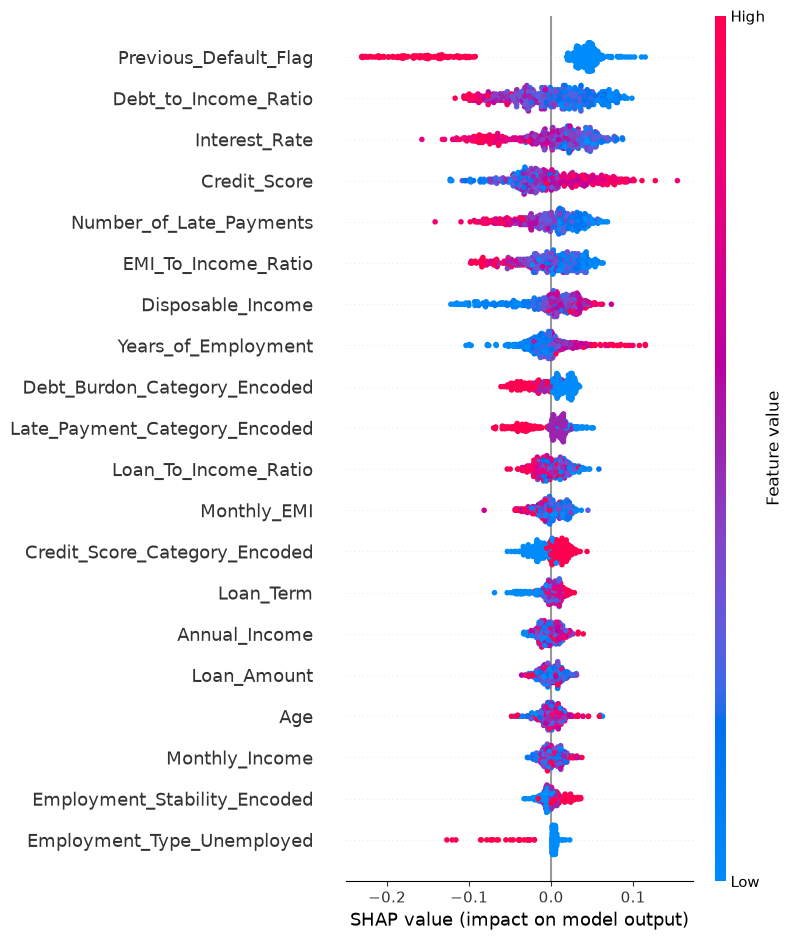

In [258]:
shap.summary_plot(
    shap_values_class1,
    x_shap,
    feature_names=x_shap.columns
)

In [259]:
shap_importance = pd.DataFrame({
    "Feature": x_shap.columns,
    "SHAP_Importance": np.abs(shap_values_class1).mean(axis=0)
}).sort_values(
    by="SHAP_Importance",
    ascending=False
)

shap_importance

,Feature,SHAP_Importance
16,Previous_Default_Flag,0.070237
8,Debt_to_Income_Ratio,0.039569
6,Interest_Rate,0.038105
9,Credit_Score,0.035285
10,Number_of_Late_Payments,0.028174
13,EMI_To_Income_Ratio,0.027952
14,Disposable_Income,0.025869
2,Years_of_Employment,0.019733
33,Debt_Burdon_Category_Encoded,0.019176
34,Late_Payment_Category_Encoded,0.017967


### Step 6: Train-Test Split
Split the dataset into:
•	Training Data: 80%
•	Testing Data: 20%
Use Stratified Train-Test Split to maintain the same proportion of approved and rejected applications in both datasets.


In [260]:
x = df.drop(["Loan_Status","Applicant_ID"], axis=1)  #we should remove APplicant_ID also because that is unique value and may be identifier for result
y = df["Loan_Status"]

In [261]:
x.shape, y.shape

((10000, 52), (10000,))

In [262]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [263]:
print("x_train : ",x_train.shape)
print("x_test : ", x_test.shape)
print("y_train : ",y_train.shape)
print("y_test : ", y_test.shape)

x_train :  (8000, 52)
x_test :  (2000, 52)
y_train :  (8000,)
y_test :  (2000,)


### Step 7: Handle Class Imbalance (If Required)


In [264]:
y_train.value_counts()

Loan_Status
0    4512
1    3488
Name: count, dtype: int64

In [265]:
# we can check percentage of data balance
y_train.value_counts(normalize=True)*100      # there is not serious imbalanced data. so no need to sampling

Loan_Status
0    56.4
1    43.6
Name: proportion, dtype: float64

In [266]:
# from imblearn.over_sampling import SMOTE

In [267]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)

# x_train_smote, y_train_smote = smote.fit_resample(
#     x_train,
#     y_train
# )

# print("Before SMOTE:")
# print(y_train.value_counts())

# print("\nAfter SMOTE:")
# print(y_train_smote.value_counts())

In [268]:
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)

# x_train_over, y_train_over = ros.fit_resample(
#     x_train,
#     y_train
# )

# print("Before Oversampling:")
# print(y_train.value_counts())

# print("\nAfter Oversampling:")
# print(y_train_over.value_counts())

In [269]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)

# x_train_under, y_train_under = rus.fit_resample(
#     x_train,
#     y_train
# )

# print("Before Undersampling:")
# print(y_train.value_counts())

# print("\nAfter Undersampling:")
# print(y_train_under.value_counts())

### Step 8: Model Development

### before step 8. we will select our imp feature. earlier we analyzed but final selection we will do now, because data leakage prevention

In [270]:
print(np.size(mi_features))
mi_features

37


['Age',
 'Dependents',
 'Years_of_Employment',
 'Monthly_Income',
 'Loan_Amount',
 'Loan_Term',
 'Interest_Rate',
 'Monthly_EMI',
 'Debt_to_Income_Ratio',
 'Credit_Score',
 'Number_of_Late_Payments',
 'Annual_Income',
 'Loan_To_Income_Ratio',
 'EMI_To_Income_Ratio',
 'Disposable_Income',
 'Existing_Loan_Flag',
 'Previous_Default_Flag',
 'Gender_Encoded',
 'Marital_Status_Divorced',
 'Marital_Status_Married',
 'Marital_Status_Single',
 'Marital_Status_Unknown',
 'Marital_Status_Widowed',
 'Education_Encoder',
 'Employment_Type_Business Owner',
 'Employment_Type_Salaried',
 'Employment_Type_Self-Employed',
 'Employment_Type_Unemployed',
 'Loan_Purpose_Frequency',
 'Age_group_Encoded',
 'Income_Category_Encoded',
 'Employment_Stability_Encoded',
 'Credit_Score_Category_Encoded',
 'Debt_Burdon_Category_Encoded',
 'Late_Payment_Category_Encoded',
 'Loan_Amount_Category_Encoded',
 'Interest_Rate_Category_Encoded']

In [271]:
# we selected the related features to target column
x_train_model = x_train[mi_features]
x_test_model = x_test[mi_features]

print("x_train_model : ",x_train_model.shape)
print("x_test_model : ", x_test_model.shape)

x_train_model :  (8000, 37)
x_test_model :  (2000, 37)


#### we will scale data for logistic regression model

#### step 1. Standard Scaler

In [272]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
x_train_scaled = std_scaler.fit_transform(x_train_model)
x_test_scaled = std_scaler.transform(x_test_model)        # for test we only do transform ,   not fit_transform

In [273]:
print("x_train_scaled : ",x_train_scaled.shape)
print("x_test_scaled : ", x_test_scaled.shape)

x_train_scaled :  (8000, 37)
x_test_scaled :  (2000, 37)


#### 8.1 Logistic Regression Model development

In [274]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train_scaled, y_train)           #Train the model : Use the scaled training data:


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [275]:
y_pred_log = log_reg.predict(x_test_scaled)         # Make predictions

In [276]:
# check accuracy for now
from sklearn.metrics import accuracy_score

accuracy_log = accuracy_score(y_test, y_pred_log)

print("logistic regression accuracy : ",accuracy_log)      #   logistic regression ==>  72.65%

logistic regression accuracy :  0.7265


#### 8.2. develop Decision Tree Model

In [277]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_model, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [278]:
y_pred_dt = dt.predict(x_test_model)
accuracy__dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree accuracy score : ", accuracy__dt)   # Decision Tree → 64.10%

Decision Tree accuracy score :  0.641


#### 8.3. develop Random forest model

In [279]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,
                                 random_state=42)
rf_model.fit(x_train_model, y_train)

y_pred_rf = rf_model.predict(x_test_model)
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
print("Random Forest accuracy : ", accuracy_rf)    #  Random Forest accuracy :  71.6%

Random Forest accuracy :  0.716


### Step 9: Hyperparameter Tuning


#### 9.1 tuning Decision Tree

In [280]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

dt_model = DecisionTreeClassifier(random_state=42)
para_grid = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,5,10],
    "max_features":[None, "sqrt", "log2"]
}

dt_grid_cv = GridSearchCV(estimator=dt_model, param_grid=para_grid, n_jobs=-1, cv=5, scoring="roc_auc")

dt_grid_cv.fit(x_train_model, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [288]:
print("Best Parameters:")
print(dt_grid_cv.best_params_)
print("\nBest CV ROC-AUC:")
print(dt_grid_cv.best_score_)

Best Parameters:
{'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best CV ROC-AUC:
0.7768421207420214


In [282]:
best_dt = dt_grid_cv.best_estimator_

In [283]:
y_pred_dt_tuned = best_dt.predict(x_test_model)
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
print("Tuned Decision Tree Accuracy : ", accuracy_dt_tuned)       #  Tuned Decision Tree Accuracy : 0.6995 

Tuned Decision Tree Accuracy :  0.6995


#### 9.2 tuning Random Forest 

In [286]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(random_state=42)

para_grid = {
    "n_estimators":[50, 100, 200, 300 ],
    "max_depth":[5,10,15],
    "min_samples_split":[2,5,10,20],
    "min_samples_leaf":[1,2,5,10],
    "max_features":[None, "sqrt", "log2"]
}

rf_random_cv = RandomizedSearchCV(estimator=rf_model,
                                 param_distributions = para_grid,
                                 n_iter = 20,
                                 cv=5,
                                 scoring= "roc_auc",
                                 random_state=42,
                                 n_jobs= -1)

rf_random_cv.fit(x_train_model, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Al

In [287]:
print("Best Parameters:")
print(rf_random_cv.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_random_cv.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 15}

Best CV ROC-AUC:
0.796492597698343


In [289]:
best_rf = rf_random_cv.best_estimator_

In [291]:
y_pred_rf_tuned = best_rf.predict(x_test_model)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
print("tuned Random Forest accuracy : ", accuracy_rf_tuned)    # tuned Random Forest accuracy : 72.1%

tuned Random Forest accuracy :  0.721


#### 9.3 tuning Logistic Regression

In [294]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_model = LogisticRegression(max_iter=2000)
para_grid = {
    "C":[0.001, 0.01, 0.1, 1, 10, 100],
    "penalty":["l2","l1"],
    "solver":["lbfgs"]
}

log_grid_cv = GridSearchCV(estimator=log_model,
                          param_grid=para_grid,
                          n_jobs=-1,
                          cv=5,
                          scoring="roc_auc")

log_grid_cv.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=2000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l2', 'l1'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

In [295]:
print("best parameters :")
print(log_grid_cv.best_params_)

print("\n Best CV roc_auc :")
print(log_grid_cv.best_score_)

best parameters :
{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

 Best CV roc_auc :
0.8013023324275921


In [296]:
best_log = log_grid_cv.best_estimator_

In [298]:
y_pred_log_tuned = best_log.predict(x_test_scaled)
accuracy_log_tuned = accuracy_score(y_test, y_pred_log_tuned)
print("tuned logistic regression accuracy : ", accuracy_log_tuned)

tuned logistic regression accuracy :  0.7245


In [ ]:
# just example for checking training accuracy.  

# y_train_pred_log = best_log.predict(x_train_scaled)

# train_accuracy_log = accuracy_score(
#     y_train,
#     y_train_pred_log
# )

# print("Logistic Regression Training Accuracy:", train_accuracy_log)

### Step 10: Model Evaluation


#### 10.1–10.5: Main classification metrics

In [301]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [302]:
# get prediction and probabilities

# Logistic Regression
y_pred_log = best_log.predict(x_test_scaled)
y_prob_log = best_log.predict_proba(x_test_scaled)[:, 1]

# Decision Tree
y_pred_dt = best_dt.predict(x_test_model)
y_prob_dt = best_dt.predict_proba(x_test_model)[:,1]

# Random Forest
y_pred_rf = best_rf.predict(x_test_model)
y_prob_rf = best_rf.predict_proba(x_test_model)[:, 1]


In [322]:
models = {
    "Logistic Regression": (y_pred_log, y_prob_log),
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "Random Forest" : (y_pred_rf , y_prob_rf)
}

for name, (y_pred, y_prob) in models.items():
    print("\n", name)
    print("-" * 40)

    print("Accuracy : ",accuracy_score(y_test, y_pred))
    print("Precision : ", precision_score(y_test, y_pred))
    print("Recall : ", recall_score(y_test , y_pred))
    print("F1 score : ", f1_score(y_test, y_pred))
    print("ROC AUC Score : ",roc_auc_score(y_test, y_prob))


 Logistic Regression
----------------------------------------
Accuracy :  0.7245
Precision :  0.6698412698412698
Recall :  0.7259174311926605
F1 score :  0.6967528893780958
ROC AUC Score :  0.8040668309584229

 Decision Tree
----------------------------------------
Accuracy :  0.6995
Precision :  0.6232939035486806
Recall :  0.7855504587155964
F1 score :  0.6950786402841197
ROC AUC Score :  0.7723125691326697

 Random Forest
----------------------------------------
Accuracy :  0.721
Precision :  0.6670212765957447
Recall :  0.7190366972477065
F1 score :  0.6920529801324503
ROC AUC Score :  0.797464661005921


#### Next: 10.6 Confusion Matrix

In [323]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test , y_pred_log)
cm_dt = confusion_matrix(y_test , y_pred_dt)
cm_rf = confusion_matrix(y_test , y_pred_rf)

print("Logistic Regression")
print(cm_log)

print("\nDecision Tree")
print(cm_dt)

print("\n Random Forest")
print(cm_rf)

Logistic Regression
[[816 312]
 [239 633]]

Decision Tree
[[714 414]
 [187 685]]

 Random Forest
[[815 313]
 [245 627]]


#### Step 10.7 — Precision-Recall Curve.

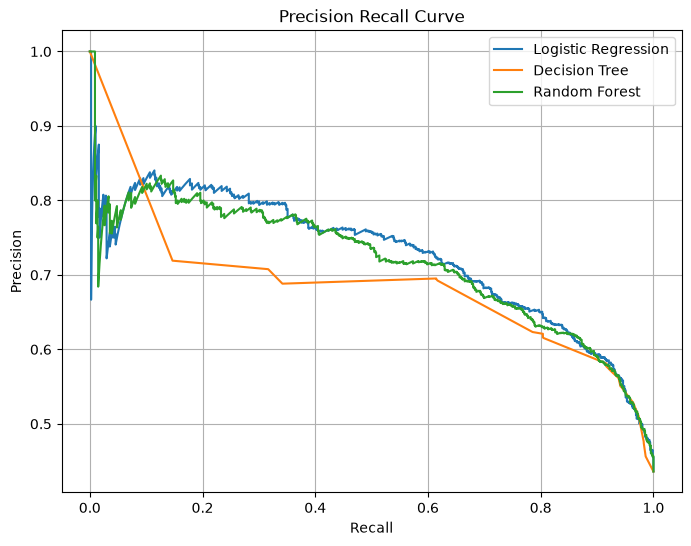

In [324]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_log , recall_log, _ = precision_recall_curve(y_test, y_prob_log)

precision_dt , recall_dt , _ = precision_recall_curve(y_test, y_prob_dt)

precision_rf , recall_rf , _ = precision_recall_curve(y_test , y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(recall_log,
        precision_log,
        label="Logistic Regression")

plt.plot(
    recall_dt,
    precision_dt,
    label="Decision Tree")

plt.plot(recall_rf,
        precision_rf,
        label = "Random Forest")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()
plt.grid()

plt.show()


#### 10.8 KS Statistic

In [325]:
from sklearn.metrics import roc_curve

def calculate_ks(y_true , y_prob):
    fpr , tpr , threshold = roc_curve(y_true, y_prob)

    ks_values = np.abs(tpr - fpr)
    ks = np.max(ks_values)

    return ks

In [326]:
ks_log = calculate_ks(y_test , y_prob_log)
ks_dt = calculate_ks(y_test , y_prob_dt)
ks_rf = calculate_ks(y_test , y_prob_rf)

print("Logistic Regression KS : ", ks_log)
print("Decision Tree KS : ", ks_dt)
print("Random Forest KS : ", ks_rf)


Logistic Regression KS :  0.46989068904938514
Decision Tree KS :  0.4244664584553322
Random Forest KS :  0.4537380441147765


#### 10.9 Gini Coefficient

In [327]:
gini_log = 2 * roc_auc_score(y_test , y_prob_log) - 1
gini_dt = 2 * roc_auc_score(y_test , y_prob_dt) - 1
gini_rf = 2 * roc_auc_score(y_test , y_prob_rf) - 1

print("Logistic Regression gini : ", gini_log)
print("Decision Tree gini : ", gini_dt)
print("Random Forest gini : ", gini_rf)

Logistic Regression gini :  0.6081336619168458
Decision Tree gini :  0.5446251382653393
Random Forest gini :  0.5949293220118419


### Step 11: Model Validation
Validate model stability using:
•	K-Fold Cross Validation
•	Stratified K-Fold Cross Validation

#### 11.1 Logistic regression

In [331]:
# we used  Model Validation: Use Stratified K-Fold Cross-Validation to validate model stability while maintaining the class distribution in each fold.
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True , random_state=42)

cv_scores_log = cross_val_score(best_log , 
                               x_train_scaled,
                               y_train,
                               cv=skf,
                               scoring="roc_auc"
                               )

print("Logistic Regression CV ROC_AUC score : ")
print(cv_scores_log)

print("\nMean CV ROC AUC : ", cv_scores_log.mean())
print("\nstd CV ROC AUC : ", cv_scores_log.std())     # High Mean + Low Standard Deviation = Good and stable model

Logistic Regression CV ROC_AUC score : 
[0.79077871 0.80643034 0.80179988 0.79879955 0.80453974]

Mean CV ROC AUC :  0.8004696433442596

std CV ROC AUC :  0.005487597717459326


#### 11.2 Decision Tree

In [332]:
cv_score_dt = cross_val_score(
    best_dt,
    x_train_model,
    y_train,
    cv=skf,
    scoring="roc_auc"
)

print("Decision Tree CV ROC AUC : ")
print(cv_score_dt)

print("\nMean CV ROC-AUC : ", cv_score_dt.mean())
print("\nstd CV ROC-AUC : ", cv_score_dt.std())

Decision Tree CV ROC AUC : 
[0.7699554  0.77307667 0.78079673 0.77221663 0.7724922 ]

Mean CV ROC-AUC :  0.7737075272317936

std CV ROC-AUC :  0.003699542268335706


#### 11.3 Random Forest

In [333]:
cv_score_rf = cross_val_score(
    best_rf,
    x_train_model,
    y_train,
    cv=skf,
    scoring="roc_auc"
)

print("RAndom Forest CV ROC_AUC : ")
print(cv_score_rf)

print("\nMean CV ROC-AUC : ",cv_score_rf.mean())
print("\nstd CV ROC-AUC : ", cv_score_rf.std())

RAndom Forest CV ROC_AUC : 
[0.79147779 0.79598374 0.80143457 0.78566732 0.80097078]

Mean CV ROC-AUC :  0.7951068398190922

std CV ROC-AUC :  0.005957675834982853


### Step 12: Model Explainability


In [334]:
import shap
explainer = shap.TreeExplainer(best_rf)              # create shap exaplainer

In [335]:
# calculate shap values

x_shap_final = x_test_model.iloc[:500]
shap_values_final = explainer.shap_values(x_shap_final)
print(type(shap_values_final))

<class 'numpy.ndarray'>


In [336]:
print(np.array(shap_values_final).shape)

(500, 37, 2)


In [337]:
shap_values_class1_final = shap_values_final[:,:,1]
print(shap_values_class1_final.shape)

(500, 37)


#### 12.1 shap summary plot

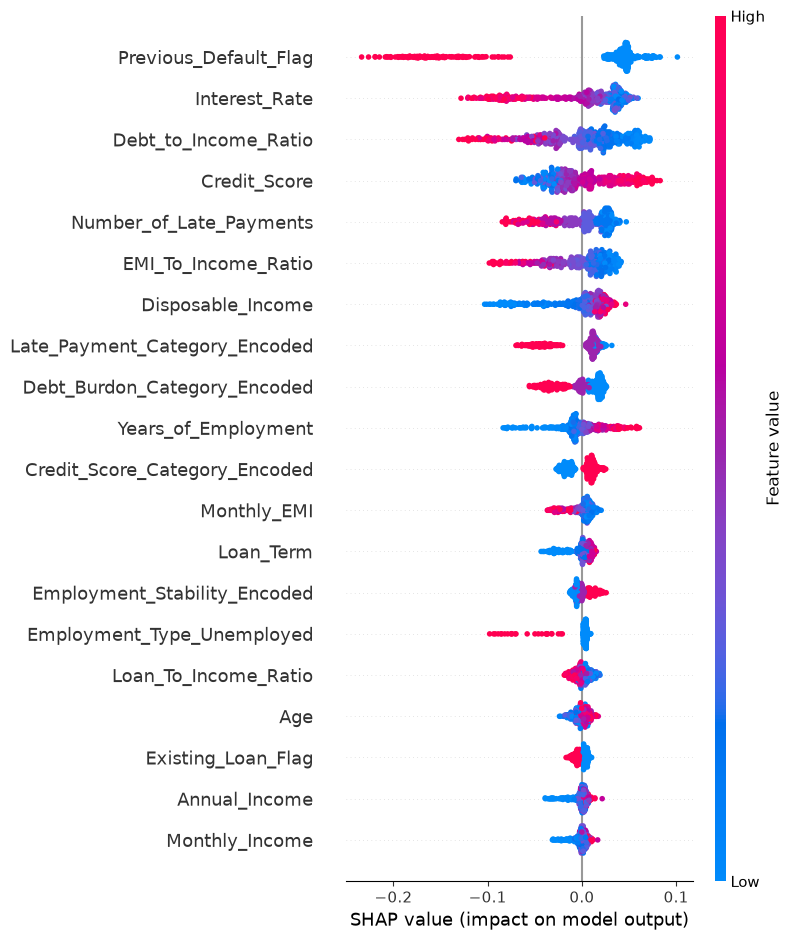

In [338]:
shap.summary_plot(shap_values_class1_final,
                  x_shap_final, 
                  feature_names=x_shap_final.columns)

#### 12.2 SHAP Feature Importance Plot


In [339]:
shap_importance = np.abs(shap_values_class1_final).mean(axis=0)
shap_importance_df = pd.DataFrame({
    "Feature": x_shap_final.columns,
    "SHAP_Importance": shap_importance
    }).sort_values(by="SHAP_Importance", 
                  ascending=False)
shap_importance_df

,Feature,SHAP_Importance
16,Previous_Default_Flag,0.071141
6,Interest_Rate,0.036965
8,Debt_to_Income_Ratio,0.036040
9,Credit_Score,0.029706
10,Number_of_Late_Payments,0.025452
13,EMI_To_Income_Ratio,0.025418
14,Disposable_Income,0.022133
34,Late_Payment_Category_Encoded,0.021370
33,Debt_Burdon_Category_Encoded,0.018213
2,Years_of_Employment,0.016168


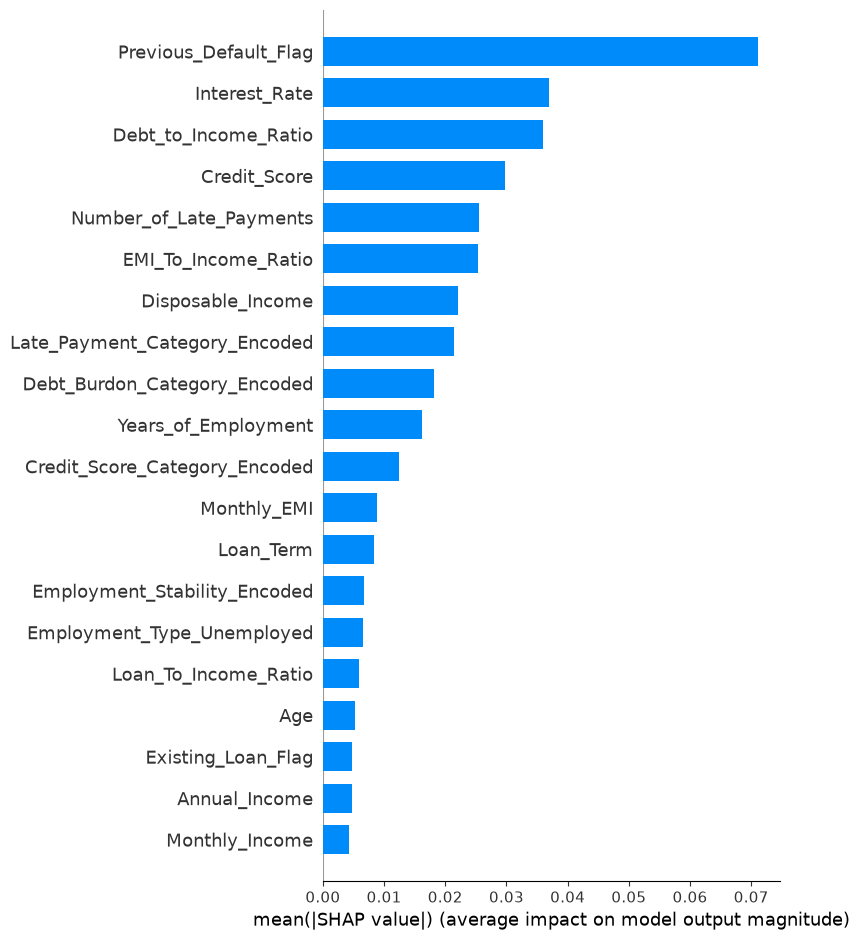

In [340]:
shap.summary_plot(
    shap_values_class1_final,
    x_shap_final,
    feature_names=x_shap_final.columns,
    plot_type="bar"
)

#### 12.3 SHAP Dependence Plot

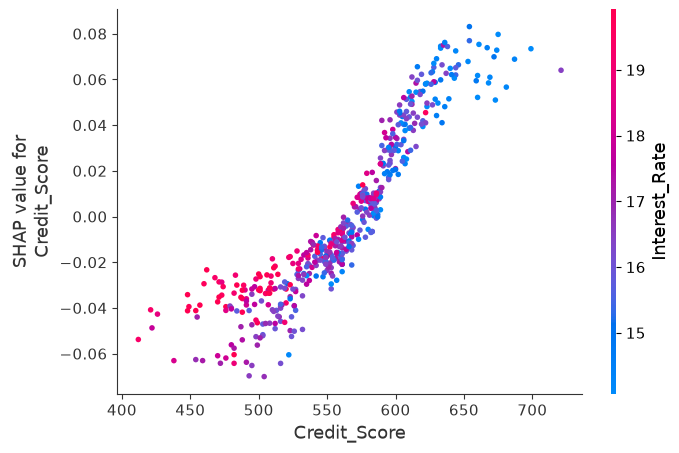

In [341]:
shap.dependence_plot(
    "Credit_Score",
    shap_values_class1_final,
    x_shap_final
)

#### 12.4 SHAP Waterfall Plot (optional)


In [342]:
# Individual applicant-level explanation
applicant_index = 0

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


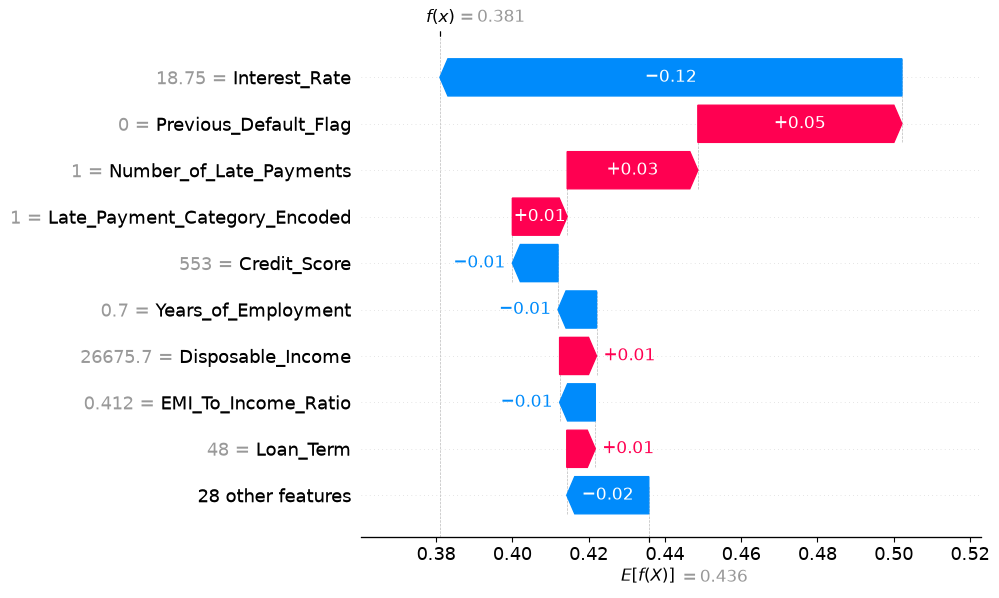

In [343]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_class1_final[applicant_index],
        base_values= explainer.expected_value[1],
        data = x_shap_final.iloc[applicant_index],
        feature_names=x_shap_final.columns
    )
)

### Step 13: Model Comparison


#### 13.1 — Create Model Comparison Table

In [344]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ],

    "KS": [
        ks_log,
        ks_dt,
        ks_rf
    ],

    "Gini": [
        gini_log,
        gini_dt,
        gini_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,KS,Gini
0,Logistic Regression,0.7245,0.669841,0.725917,0.696753,0.804067,0.469891,0.608134
1,Decision Tree,0.6995,0.623294,0.785550,0.695079,0.772313,0.424466,0.544625
2,Random Forest,0.7210,0.667021,0.719037,0.692053,0.797465,0.453738,0.594929


#### 13.2 — Add Training Time

In [346]:
import time

# Logistic Regression
start = time.perf_counter()
best_log.fit(x_train_scaled,y_train)
log_time = time.perf_counter() - start

# Decision Tree
start = time.perf_counter()
best_dt.fit(x_train_model,y_train)
dt_time = time.perf_counter() - start

# Random Forest
start = time.perf_counter()
best_rf.fit(x_train_model,y_train)
rf_time = time.perf_counter() - start

print("Logistic Regression Training Time :", log_time)
print("Decision Tree Training Time       :", dt_time)
print("Random Forest Training Time       :", rf_time)

Logistic Regression Training Time : 0.03041439998196438
Decision Tree Training Time       : 0.07272419997025281
Random Forest Training Time       : 2.818486899952404


In [347]:
comparison["Training Time (sec)"] = [
    log_time,
    dt_time,
    rf_time
]

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,KS,Gini,Training Time (sec)
0,Logistic Regression,0.7245,0.669841,0.725917,0.696753,0.804067,0.469891,0.608134,0.030414
1,Decision Tree,0.6995,0.623294,0.785550,0.695079,0.772313,0.424466,0.544625,0.072724
2,Random Forest,0.7210,0.667021,0.719037,0.692053,0.797465,0.453738,0.594929,2.818487


In [348]:
# final comparision of all the models.
comparison["Interpretability"] = [
    "Very High",
    "High",
    "Moderate"
]

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,KS,Gini,Training Time (sec),Interpretability
0,Logistic Regression,0.7245,0.669841,0.725917,0.696753,0.804067,0.469891,0.608134,0.030414,Very High
1,Decision Tree,0.6995,0.623294,0.785550,0.695079,0.772313,0.424466,0.544625,0.072724,High
2,Random Forest,0.7210,0.667021,0.719037,0.692053,0.797465,0.453738,0.594929,2.818487,Moderate


## Final Selected Model is Logistic Regression

In [353]:
import shap
explainer_log = shap.Explainer(
    best_log,
    x_train_scaled
)

Background dataset has 8000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8000 when initializing the masker.


In [356]:
x_shap_log = x_test_scaled[:500]

In [357]:
shap_values_log = explainer_log(x_shap_log)

In [358]:
print(shap_values_log.values.shape)

(500, 37)


In [359]:
print(x_train_model.shape)
print(x_train_scaled.shape)

(8000, 37)
(8000, 37)


In [361]:
feature_names_log = x_train_model.columns
print(len(feature_names_log))
print(feature_names_log)

37
Index(['Age', 'Dependents', 'Years_of_Employment', 'Monthly_Income',
       'Loan_Amount', 'Loan_Term', 'Interest_Rate', 'Monthly_EMI',
       'Debt_to_Income_Ratio', 'Credit_Score', 'Number_of_Late_Payments',
       'Annual_Income', 'Loan_To_Income_Ratio', 'EMI_To_Income_Ratio',
       'Disposable_Income', 'Existing_Loan_Flag', 'Previous_Default_Flag',
       'Gender_Encoded', 'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown',
       'Marital_Status_Widowed', 'Education_Encoder',
       'Employment_Type_Business Owner', 'Employment_Type_Salaried',
       'Employment_Type_Self-Employed', 'Employment_Type_Unemployed',
       'Loan_Purpose_Frequency', 'Age_group_Encoded',
       'Income_Category_Encoded', 'Employment_Stability_Encoded',
       'Credit_Score_Category_Encoded', 'Debt_Burdon_Category_Encoded',
       'Late_Payment_Category_Encoded', 'Loan_Amount_Category_Encoded',
       'Interest_Rate_Category_Encoded'],
      

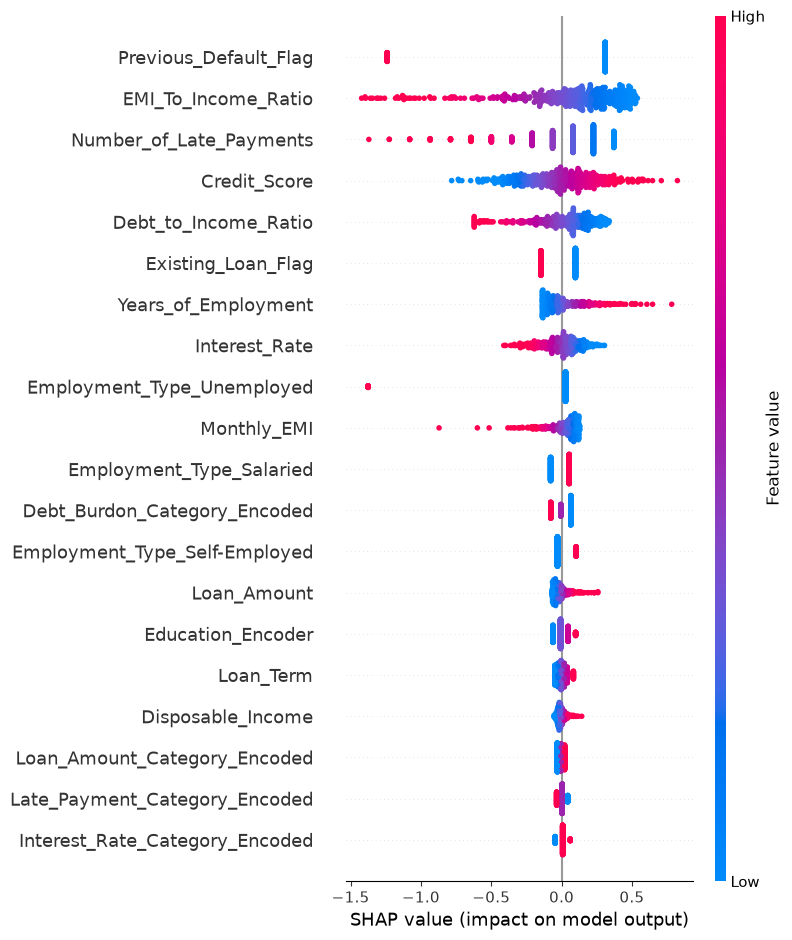

In [362]:
shap.summary_plot(
    shap_values_log.values,
    x_shap_log,
    feature_names=feature_names_log
)

In [363]:
shap_importance_log = np.abs(shap_values_log.values).mean(axis=0)

shap_importance_log_df = pd.DataFrame({
    "Feature": feature_names_log,
    "SHAP_Importance": shap_importance_log
}).sort_values(
    by="SHAP_Importance",
    ascending=False
)

shap_importance_log_df

,Feature,SHAP_Importance
16,Previous_Default_Flag,0.523658
13,EMI_To_Income_Ratio,0.302307
10,Number_of_Late_Payments,0.251711
9,Credit_Score,0.210075
8,Debt_to_Income_Ratio,0.169863
15,Existing_Loan_Flag,0.120631
2,Years_of_Employment,0.114309
6,Interest_Rate,0.105049
27,Employment_Type_Unemployed,0.098118
7,Monthly_EMI,0.084877


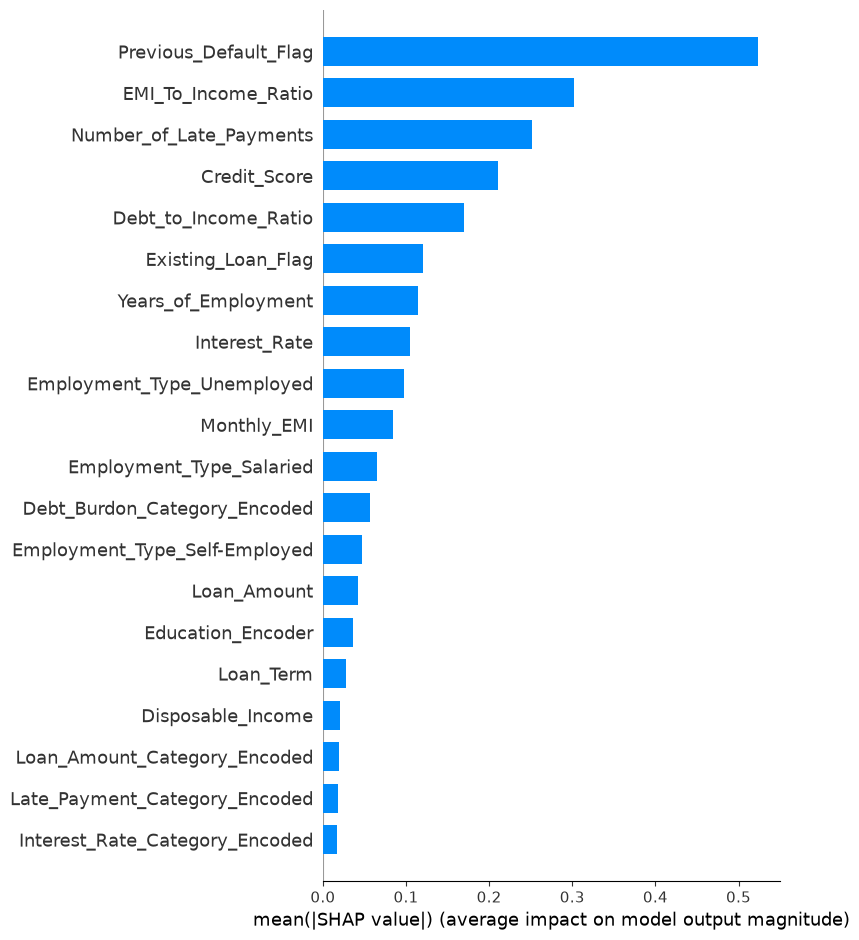

In [364]:
shap.summary_plot(
    shap_values_log.values,
    x_shap_log,
    feature_names=feature_names_log,
    plot_type="bar"
)

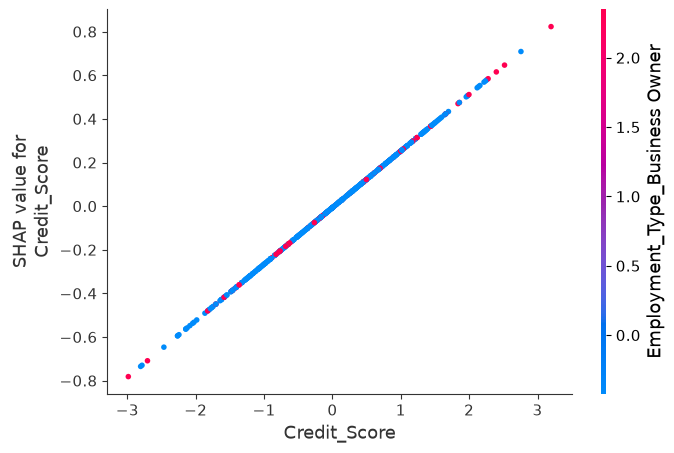

In [366]:
shap.dependence_plot(
    "Credit_Score",
    shap_values_log.values,
    x_shap_log,
    feature_names=feature_names_log
)

In [367]:
applicant_index_log = 0

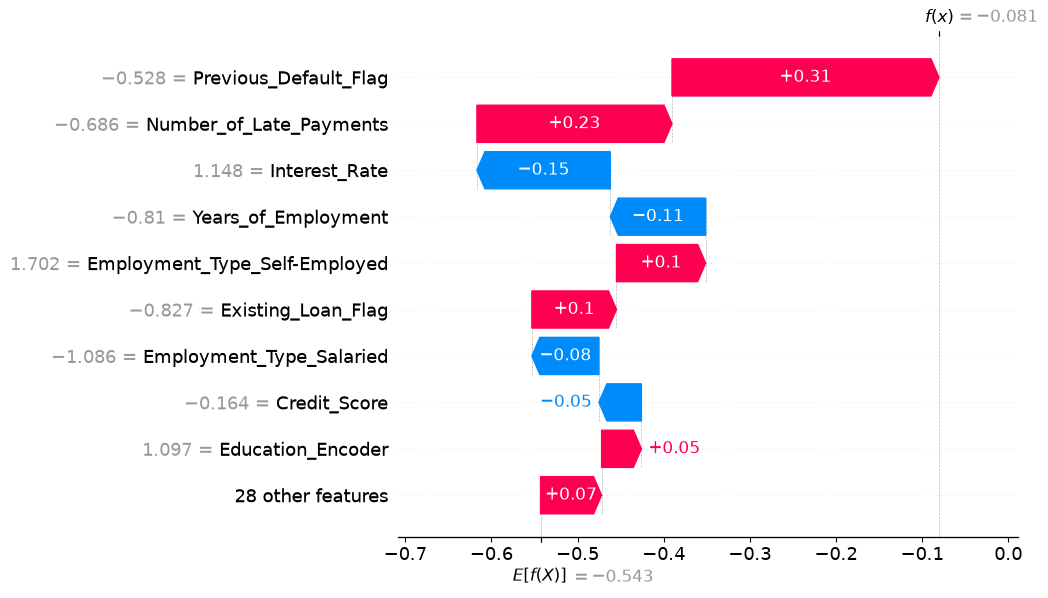

In [368]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_log.values[applicant_index_log],
        base_values=shap_values_log.base_values[applicant_index_log],
        data=x_shap_log[applicant_index_log],
        feature_names=feature_names_log
    )
)

### phase 1: Create Models folder and save Logistic Regression model there

In [370]:
import os
os.makedirs("models", exist_ok=True)
print("Models folder created")

Models folder created


In [372]:
import pickle

with open("models/loan_approval_model.pkl", "wb") as file:
    pickle.dump(best_log, file)

print("Final model saved successfully.")

# best_log = object we want to save
# file = opened file where we save it
# pickle.dump() = the action that saves the object

Final model saved successfully.


In [373]:
with open("models/standard_scaler.pkl", "wb") as file:
    pickle.dump(std_scaler, file)

print("standard scaler saved successfully.")

standard scaler saved successfully.


In [374]:
with open("models/selected_features.pkl", "wb") as file:
    pickle.dump(mi_features, file)

print("selected features saved successfully")

selected features saved successfully


#### json file

In [387]:
{
    "gender": {
        "Male": 0,
        "Female": 1,
        "Unknown": 2
    },

    "education": {
        "High School": 0,
        "Graduate": 1,
        "Post Graduate": 2,
        "Doctorate": 3
    },

    "age_group": {
        "Young": 0,
        "Adult": 1,
        "Middle": 2,
        "Senior": 3
    },

    "income_category": {
        "Low Income": 0,
        "Medium Income": 1,
        "High Income": 2,
        "Very High Income": 3
    },

    "employment_stability": {
        "New Employee": 0,
        "Experienced Employee": 1,
        "Highly Experienced Employee": 2
    },

    "credit_score_category": {
        "Poor": 0,
        "Fair": 1,
        "Good": 2,
        "Very Good": 3
    },

    "debt_burden_category": {
        "Low Risk": 0,
        "Moderate Risk": 1,
        "High Risk": 2
    },

    "late_payment_category": {
        "No Delay": 0,
        "Few Delays": 1,
        "Frequent Delays": 2
    },

    "loan_amount_category": {
        "Small Loan": 0,
        "Medium Loan": 1,
        "Large Loan": 2
    },

    "interest_rate_category": {
        "Low Interest": 0,
        "Medium Interest": 1,
        "High Interest": 2
    },

    "existing_loan": {
        "Yes": 1,
        "No": 0
    },

    "previous_default": {
        "Yes": 1,
        "No": 0
    },

    "marital_status": [
        "Divorced",
        "Married",
        "Single",
        "Unknown",
        "Widowed"
    ],

    "employment_type": [
        "Business Owner",
        "Salaried",
        "Self-Employed",
        "Unemployed"
    ],

    "loan_purpose_frequency": {
        "Debt Consolidation": 0.1691,
        "Business": 0.152,
        "Home Renovation": 0.146,
        "Education": 0.1218,
        "Medical": 0.1159,
        "Other": 0.1056,
        "Wedding": 0.1002,
        "Travel": 0.0795,
        "Unknown": 0.0099
    },

    "age_bins": [
        17,
        30,
        45,
        60,
        "inf"
    ],

    "income_quantiles": [
        25775,
        38400,
        57000
    ],

    "category_rules": {
        "employment_stability": {
            "new_employee_max": 2,
            "experienced_employee_max": 5
        },

        "credit_score": {
            "poor": [300, 549],
            "fair": [550, 649],
            "good": [650, 749],
            "very_good": [750, 799],
            "excellent": [800, 900]
        },

        "debt_burden": {
            "low_risk_max": 0.35,
            "moderate_risk_max": 0.50
        },

        "late_payment": {
            "no_delay": 0,
            "few_delays_max": 3
        },

        "loan_amount": {
            "small_max": 207670,
            "medium_max": 413000
        },

        "interest_rate": {
            "low_max": 15,
            "medium_max": 20
        }
    },

    "columns": [
        "Age",
        "Dependents",
        "Years_of_Employment",
        "Monthly_Income",
        "Loan_Amount",
        "Loan_Term",
        "Interest_Rate",
        "Monthly_EMI",
        "Debt_to_Income_Ratio",
        "Credit_Score",
        "Number_of_Late_Payments",
        "Annual_Income",
        "Loan_To_Income_Ratio",
        "EMI_To_Income_Ratio",
        "Disposable_Income",
        "Existing_Loan_Flag",
        "Previous_Default_Flag",
        "Gender_Encoded",
        "Marital_Status_Divorced",
        "Marital_Status_Married",
        "Marital_Status_Single",
        "Marital_Status_Unknown",
        "Marital_Status_Widowed",
        "Education_Encoder",
        "Employment_Type_Business Owner",
        "Employment_Type_Salaried",
        "Employment_Type_Self-Employed",
        "Employment_Type_Unemployed",
        "Loan_Purpose_Frequency",
        "Age_group_Encoded",
        "Income_Category_Encoded",
        "Employment_Stability_Encoded",
        "Credit_Score_Category_Encoded",
        "Debt_Burdon_Category_Encoded",
        "Late_Payment_Category_Encoded",
        "Loan_Amount_Category_Encoded",
        "Interest_Rate_Category_Encoded"
    ]
}

{'gender': {'Male': 0, 'Female': 1, 'Unknown': 2},
 'education': {'High School': 0,
  'Graduate': 1,
  'Post Graduate': 2,
  'Doctorate': 3},
 'age_group': {'Young': 0, 'Adult': 1, 'Middle': 2, 'Senior': 3},
 'income_category': {'Low Income': 0,
  'Medium Income': 1,
  'High Income': 2,
  'Very High Income': 3},
 'employment_stability': {'New Employee': 0,
  'Experienced Employee': 1,
  'Highly Experienced Employee': 2},
 'credit_score_category': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3},
 'debt_burden_category': {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2},
 'late_payment_category': {'No Delay': 0,
  'Few Delays': 1,
  'Frequent Delays': 2},
 'loan_amount_category': {'Small Loan': 0, 'Medium Loan': 1, 'Large Loan': 2},
 'interest_rate_category': {'Low Interest': 0,
  'Medium Interest': 1,
  'High Interest': 2},
 'existing_loan': {'Yes': 1, 'No': 0},
 'previous_default': {'Yes': 1, 'No': 0},
 'marital_status': ['Divorced', 'Married', 'Single', 'Unknown', 'Widowed'],
 'em

In [388]:
with open("models/preprocessing_config.json", "w") as file:
    json.dump(preprocessing_config, file, indent=4)

print("Preprocessing configuration saved successfully")

Preprocessing configuration saved successfully


In [389]:
with open("models/preprocessing_config.json", "r") as file:
    pl_loan_data = json.load(file)

print("Preprocessing configuration loaded successfully")
print(pl_loan_data.keys())

Preprocessing configuration loaded successfully
dict_keys(['gender_mapping', 'education_mapping', 'income_mapping', 'employment_stability_mapping', 'credit_score_mapping', 'debt_burden_mapping', 'late_payment_mapping', 'loan_amount_mapping', 'interest_rate_mapping', 'marital_status_categories', 'employment_type_categories', 'loan_purpose_frequency', 'age_bins', 'income_quantiles', 'selected_features', 'age_group_mapping', 'existing_loan_mapping', 'previous_default_mapping', 'category_rules'])
